# <span style="color:#1A5265;">Analyse exploratoire : </span>

### **Introduction contextuelle**
Le secteur de l'assurance automobile et/ou de la gestion de flottes de véhicules fait face à la nécessité d'anticiper avec précision les dépenses futures liées à la maintenance et aux réparations. Une sous-estimation de ces coûts impacte directement la rentabilité et la tarification des polices d'assurance ou des budgets d'exploitation.

Le dataset fourni, comprenant des variables clés comme l'âge du véhicule (Vehicle_Age_Yrs), l'usage (Usage_Type), le kilométrage quotidien (Avg_Daily_Mileage), et le type de moteur (Engine_Displacement_L), a pour objectif de modéliser la relation entre ces caractéristiques et la dépense annuelle de réparation (Annual_Repair_Cost).

### **Conséquence Économique (Enjeu Business)**
Le modèle de prédiction du Coût Annuel de Réparation (Annual_Repair_Cost) a un impact économique direct sur trois acteurs principaux :

#### 1. Pour les Compagnies d'Assurance
Gestion du Risque : Le modèle permet une évaluation beaucoup plus fine du risque de sinistre, facilitant la tarification juste et optimisée des primes d'assurance.

Optimisation des Marges : Réduction des pertes par sous-estimation des coûts et amélioration de la marge opérationnelle.

#### 2. Pour les Individus et Propriétaires
Transparence : Meilleure compréhension des facteurs du véhicule (âge, kilométrage, modifications) qui influencent directement le coût de l'assurance et de l'entretien.

Incitations : Encourage les choix d'achat et de conduite plus responsables en liant clairement les caractéristiques du véhicule aux dépenses futures.

#### 3. Pour l'Industrie et la Société
Qualité et Durabilité : Fournit des données clés aux constructeurs pour améliorer la fiabilité des composants et réduire les coûts de réparation futurs.

Allocation des Ressources : Aide les centres de service à optimiser la localisation et la capacité des réparations en fonction de l'analyse géographique (Service_Geo_Index).

#  <span style="color:#2471A3">*Business Understanding :*</span>

### 1. Objectifs Métiers (BOs) :

#### 1 .Objectif Descriptif :
Comprendre la Distribution des Coûts : Identifier comment l'Annual_Repair_Cost se répartit selon les caractéristiques du véhicule (âge, type d'usage, kilométrage quotidien, modifications).

Identifier les Profils : Isoler les profils de véhicules les plus coûteux (ex: véhicules modifiés à usage commercial) et les moins coûteux (ex: véhicules récents à faible kilométrage).

Exemple : Comparer le coût de réparation moyen entre les véhicules ayant le Modified_Flag à 'Oui' et ceux à 'Non'.

#### 2. Objectif Analytique :
Déterminer les Facteurs Clés : Mesurer quels facteurs techniques et d'usage (Vehicle_Age_Yrs, Avg_Daily_Mileage, Modified_Flag) influencent le plus fortement les coûts de réparation.

Quantifier l'Impact : Évaluer l'augmentation monétaire moyenne du coût due à un facteur (ex: mesurer combien l'ajout d'une année d'âge ou d'un certain kilométrage supplémentaire augmente le coût annuel moyen).

Exemple : Analyser la corrélation entre la variable Avg_Daily_Mileage et l'Annual_Repair_Cost.

#### 3. Objectif Prédictif :
Prédire le Coût pour un Nouveau Véhicule : Développer un modèle de régression pour estimer l'Annual_Repair_Cost d'un véhicule qui n'a pas encore été assuré ou mis en service.

Optimisation de la Tarification : Utiliser cette estimation pour fixer la prime d'assurance ou le budget de maintenance préventive le plus juste et le plus précis pour chaque véhicule.

Exemple : Utiliser un modèle de régression pour prédire le coût en euros et l'intégrer dans le calcul de la police d'assurance.

### Objectifs Data Science (DSOs) :
#### .1. Préparation et Exploration des DonnéesNettoyage et Structure :
Gérer les données brutes : nettoyer les valeurs manquantes si elles existent, encoder les variables catégorielles (Usage_Type, Modified_Flag, Service_Geo_Index) et normaliser les variables numériques (âge, kilométrage).
Analyse des Relations : Calculer et analyser les corrélations entre les variables d'entrée (features) et la variable cible (Annual_Repair_Cost) pour orienter la modélisation.
#### 2. Analyse Descriptive et CorrélationnelleVisualisation :
Créer des graphiques (boîtes à moustaches, histogrammes) pour visualiser les distributions et les relations
Identification des Causes : Identifier statistiquement les facteurs qui entraînent la plus grande variation des coûts.
Exemple : Déterminer si les véhicules utilisés à des fins commerciales (Usage_Type) ou ceux ayant une Modified_Flag à 'Oui' coûtent significativement plus cher.
#### 3. Modélisation Prédictive
Construction du Modèle : Développer et entraîner des modèles de régression supervisée (ex: Gradient Boosting, Random Forest) pour prédire l'Annual_Repair_Cost.
Évaluation et Validation : Évaluer les performances en utilisant les métriques cibles fixées ($R^2 \geq 0.75$ et MAE $\leq 150 €$).
Livrable Technique : Fournir le modèle final capable de prédire le coût de réparation pour tout nouveau véhicule avec les caractéristiques d'entrée.

### Imporation Bibliotheques

In [ ]:
import warnings
warnings.filterwarnings('ignore') # Hides all warning messages so they don't appear in the output

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler

pd.set_option('display.max_columns', None)  # Ensures all columns are shown when displaying a DataFrame
pd.set_option('display.max_rows', None)  # Ensures all rows are shown when displaying a DataFrame

### Importation Jeu De Données

In [ ]:
df = pd.read_excel('Vehicle_Repair_Dataset_Realistic.xlsx')
df.head(10)

,Vehicle_Age_Yrs,Usage_Type,Engine_Displacement_L,Avg_Daily_Mileage,Modified_Flag,Service_Geo_Index,Annual_Repair_Cost
0,6.0,Business,NaN,86.0,Yes,Zone_B,1020.97
1,19.0,Personal,2.51,NaN,No,Zone_B,1865.68
2,14.0,Personal,1.57,68.0,Yes,Zone_A,1437.83
3,10.0,Personal,1.07,87.0,Yes,Zone_D,1020.75
4,7.0,Business,2.86,51.0,No,Zone_B,799.14
5,20.0,Personal,4.77,10.0,Yes,Zone_C,2703.34
6,6.0,Personal,2.30,20.0,Yes,Zone_D,1276.05
7,18.0,Personal,3.64,150.0,No,Zone_B,2772.63
8,10.0,Business,3.61,184.0,No,Zone_A,1388.12
9,10.0,Business,2.00,180.0,No,Zone_C,1160.66


##### Representation des 10 premieres lignes du dataset

In [ ]:
df.tail()

,Vehicle_Age_Yrs,Usage_Type,Engine_Displacement_L,Avg_Daily_Mileage,Modified_Flag,Service_Geo_Index,Annual_Repair_Cost
995,7.0,Personal,3.49,43.0,Yes,Zone_B,1344.89
996,5.0,Business,1.25,160.0,Yes,Zone_B,891.29
997,5.0,Personal,2.30,162.0,Yes,Zone_A,1058.79
998,7.0,Personal,3.69,41.0,Yes,Zone_A,1875.44
999,14.0,Business,2.35,123.0,Yes,Zone_C,1502.40


#### Representation des 5 dernieres lignes du dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Vehicle_Age_Yrs        990 non-null    float64
 1   Usage_Type             990 non-null    object 
 2   Engine_Displacement_L  990 non-null    float64
 3   Avg_Daily_Mileage      990 non-null    float64
 4   Modified_Flag          990 non-null    object 
 5   Service_Geo_Index      990 non-null    object 
 6   Annual_Repair_Cost     1000 non-null   float64
dtypes: float64(4), object(3)
memory usage: 54.8+ KB


# Analyse de la sortie `df.info()`

## 1. Taille du jeu de données
- Le DataFrame contient **1000 observations** (indexées de 0 à 999).
- Il comporte **7 colonnes**.

---

## 2. Types de données
- **4 colonnes numériques** (`float64`), dont la variable cible :  
  - `Annual_Repair_Cost`
- **3 colonnes catégorielles** (`object`) :  
  - `Usage_Type`  
  - `Modified_Flag`  
  - `Service_Geo_Index`

---

## 3. Valeurs manquantes
Six colonnes contiennent **990 valeurs non nulles**, ce qui signifie **10 valeurs manquantes** dans chacune :  
- `Vehicle_Age_Yrs`  
- `Usage_Type`  
- `Engine_Displacement_L`  
- `Avg_Daily_Mileage`  
- `Modified_Flag`  
- `Service_Geo_Index`

La variable cible **`Annual_Repair_Cost`** est complète avec **1000 valeurs non nulles**.

---

## 4. Synthèse
Le jeu de données est **presque complet** et de **taille moyenne**.  
Une étape de **nettoyage** sera nécessaire pour gérer les valeurs manquantes présentes dans la majorité des variables explicatives.

---


In [ ]:
df["Annual_Repair_Cost"].describe()

count    1000.000000
mean     1520.049890
std       650.956767
min      -217.850000
25%      1018.155000
50%      1477.245000
75%      1957.720000
max      4303.710000
Name: Annual_Repair_Cost, dtype: float64

# Annual_Repair_Cost — Analyse Descriptive

## 1. Taille de l’échantillon
- 1000 observations complètes.

---

## 2. Coût annuel moyen
- Moyenne : **1520 €**  
- Médiane : **1477 €**  
> Les deux valeurs sont proches, ce qui indique une distribution relativement symétrique.

---

## 3. Distribution des coûts
- 25ᵉ percentile : **1018 €**  
- 75ᵉ percentile : **1958 €**  
La majorité des coûts se situent donc entre **1018 € et 1958 €**.

---

## 4. Anomalies détectées
- Minimum : **–217.85 €**  
  - Valeur impossible pour un coût de réparation  
  - Probable erreur de saisie ou remboursement enregistré comme coût négatif
- Maximum : **4303.71 €**

> La valeur négative devra être examinée, corrigée ou exclue.

---


In [ ]:
df["Usage_Type"].value_counts()

Usage_Type
Business      524
Personal      463
Biz             1
Pers            1
Commerical      1
Name: count, dtype: int64

In [ ]:
df["Modified_Flag"].value_counts()

Modified_Flag
Yes        494
No         493
Y            1
N            1
Unknown      1
Name: count, dtype: int64

In [ ]:
df["Service_Geo_Index"].value_counts()

Service_Geo_Index
Zone_B    263
Zone_D    251
Zone_A    243
Zone_C    233
Name: count, dtype: int64

#### Voici quelques informations sur nos variables categorielles

## Les Données ( Qualité ) :

 Objectif : Verifier la credibilité des données

In [ ]:
missing_values = df.isnull().sum()
print(" Nombre de valeurs manquantes par colonne :\n")
print(missing_values)

 Nombre de valeurs manquantes par colonne :

Vehicle_Age_Yrs          10
Usage_Type               10
Engine_Displacement_L    10
Avg_Daily_Mileage        10
Modified_Flag            10
Service_Geo_Index        10
Annual_Repair_Cost        0
dtype: int64


In [ ]:
duplicates = df[df.duplicated()]
print("Nombre de doublons :", duplicates.shape[0])

Nombre de doublons : 0


In [ ]:
bins = [0, 2, 5, 10, float('inf')]  # intervals
labels = ['New', 'Lightly Used', 'Used', 'Old']  # category names

df['Vehicle_Age_Category'] = pd.cut(df['Vehicle_Age_Yrs'], bins=bins, labels=labels, right=True)

In [ ]:
print(df[['Vehicle_Age_Yrs', 'Vehicle_Age_Category']].head(10))
print(df['Vehicle_Age_Category'].value_counts())
df.head(20)

   Vehicle_Age_Yrs Vehicle_Age_Category
0              6.0                 Used
1             19.0                  Old
2             14.0                  Old
3             10.0                 Used
4              7.0                 Used
5             20.0                  Old
6              6.0                 Used
7             18.0                  Old
8             10.0                 Used
9             10.0                 Used
Vehicle_Age_Category
Old             461
Used            212
Lightly Used    153
New             101
Name: count, dtype: int64


,Vehicle_Age_Yrs,Usage_Type,Engine_Displacement_L,Avg_Daily_Mileage,Modified_Flag,Service_Geo_Index,Annual_Repair_Cost,Vehicle_Age_Category
0,6.0,Business,NaN,86.0,Yes,Zone_B,1020.97,Used
1,19.0,Personal,2.51,NaN,No,Zone_B,1865.68,Old
2,14.0,Personal,1.57,68.0,Yes,Zone_A,1437.83,Old
3,10.0,Personal,1.07,87.0,Yes,Zone_D,1020.75,Used
4,7.0,Business,2.86,51.0,No,Zone_B,799.14,Used
5,20.0,Personal,4.77,10.0,Yes,Zone_C,2703.34,Old
6,6.0,Personal,2.30,20.0,Yes,Zone_D,1276.05,Used
7,18.0,Personal,3.64,150.0,No,Zone_B,2772.63,Old
8,10.0,Business,3.61,184.0,No,Zone_A,1388.12,Used
9,10.0,Business,2.00,180.0,No,Zone_C,1160.66,Used


## Analyse de chaque variable

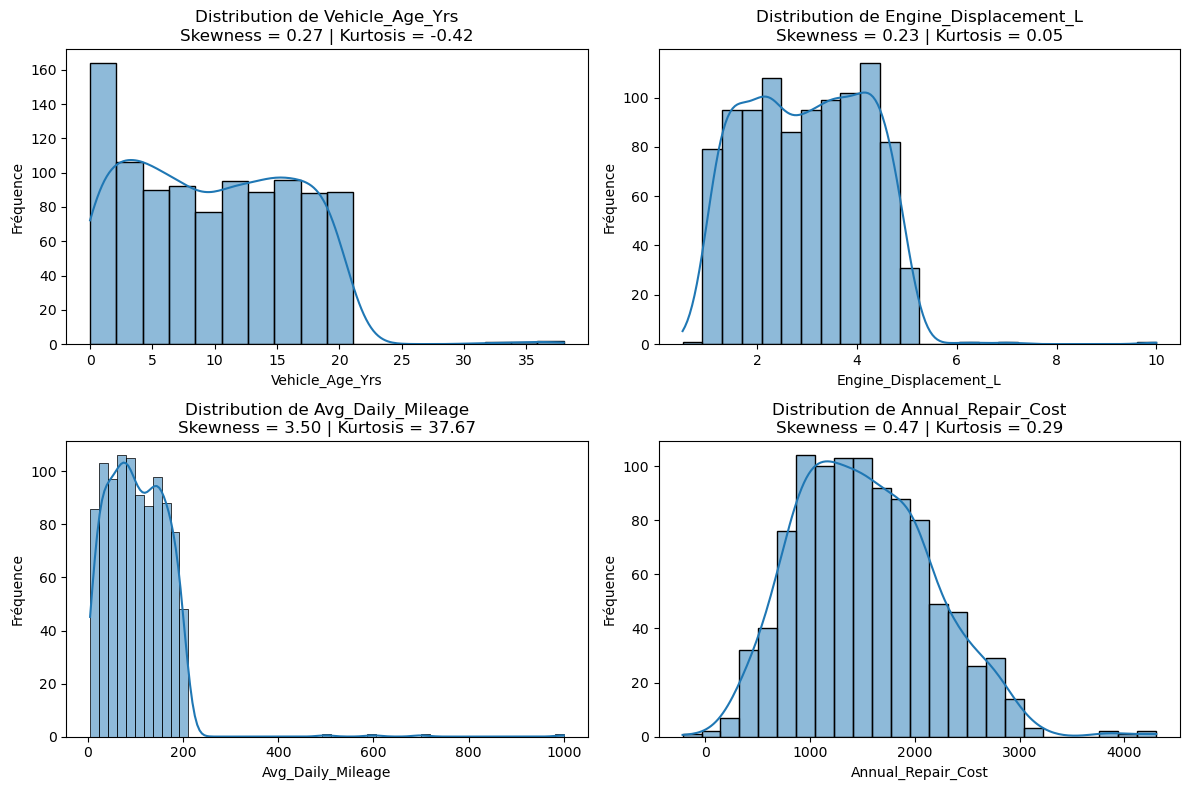

In [ ]:
# Liste des variables quantitatives
quant_vars = [
    'Vehicle_Age_Yrs',
    'Engine_Displacement_L',
    'Avg_Daily_Mileage',
    'Annual_Repair_Cost'
]

plt.figure(figsize=(12, 8))

for i, var in enumerate(quant_vars):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[var], kde=True)

    # Calcul de skewness et kurtosis
    skew_val = df[var].skew()
    kurt_val = df[var].kurtosis()

    # Titre
    plt.title(
        f"Distribution de {var}\nSkewness = {skew_val:.2f} | Kurtosis = {kurt_val:.2f}"
    )
    plt.xlabel(var)
    plt.ylabel("Fréquence")

plt.tight_layout()
plt.show()


# Analyse de la Distribution des Variables Numériques

## 1. Vehicle_Age_Yrs
- **Skewness : 0.27** → distribution légèrement asymétrique à droite.  
- **Kurtosis : -0.42** → distribution légèrement plus plate que la normale.  
> La variable `Vehicle_Age_Yrs` présente une distribution relativement symétrique et uniforme.

---

## 2. Engine_Displacement_L
- **Skewness : 0.23** → distribution légèrement asymétrique à droite.  
- **Kurtosis : 0.05** → distribution proche de la normale.  
> La variable `Engine_Displacement_L` suit une distribution quasi normale.

---

## 3. Avg_Daily_Mileage
- **Skewness : 3.50** → forte asymétrie à droite, avec plusieurs valeurs élevées.  
- **Kurtosis : 37.67** → distribution très pointue, indiquant des valeurs extrêmes importantes.  
> La variable `Avg_Daily_Mileage` est fortement asymétrique et contient plusieurs outliers ou valeurs extrêmes.

---

## 4. Annual_Repair_Cost
- **Skewness : 0.47** → asymétrie modérée à droite.  
- **Kurtosis : 0.29** → distribution légèrement plus pointue que la normale.  
> La variable cible `Annual_Repair_Cost` présente une distribution globalement symétrique avec quelques valeurs élevées.


# Propositions d'Actions Basées sur la Skewness et la Kurtosis

## 1. Vehicle_Age_Yrs (Skewness = 0.27, Kurtosis = -0.42)
- Distribution quasi symétrique et légèrement plate.
- **Action proposée :** aucune transformation nécessaire ; peut être utilisée directement pour l'analyse et la modélisation.

---

## 2. Engine_Displacement_L (Skewness = 0.23, Kurtosis = 0.05)
- Distribution très proche de la normale.
- **Action proposée :** aucune transformation nécessaire ; la variable peut être utilisée telle quelle.

---

## 3. Avg_Daily_Mileage (Skewness = 3.50, Kurtosis = 37.67)
- Forte asymétrie à droite et kurtosis très élevée → présence de valeurs extrêmes (outliers).
- **Actions proposées :**
  - Examiner et traiter les **outliers** éventuels.
  - Envisager une **transformation logarithmique ou racine carrée** pour réduire l'asymétrie et rendre la distribution plus normale.
  - Cette transformation peut améliorer les performances des modèles sensibles à la distribution des variables.

---

## 4. Annual_Repair_Cost (Skewness = 0.47, Kurtosis = 0.29)
- Asymétrie modérée et kurtosis proche de 0 → distribution légèrement inclinée à droite.
- **Actions proposées :**
  - Vérifier les **valeurs extrêmes** et décider si elles doivent être conservées ou transformées.
  - Pour certains modèles (régression linéaire, régression logistique), une **transformation légère** (log ou Box-Cox) peut être envisagée si nécessaire.


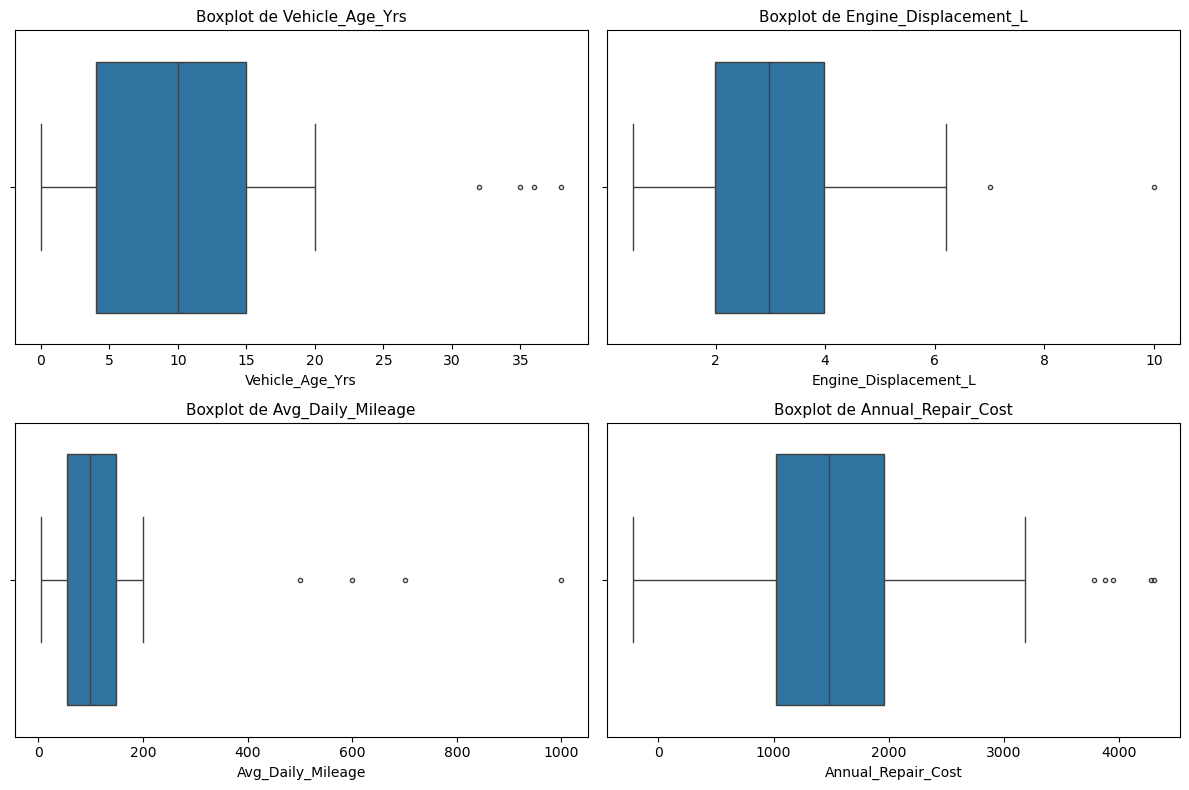

In [ ]:
# Visualisation des Boxplots pour détecter les valeurs aberrantes

# Liste des variables quantitatives
quant_vars = [
    'Vehicle_Age_Yrs',
    'Engine_Displacement_L',
    'Avg_Daily_Mileage',
    'Annual_Repair_Cost'
]

plt.figure(figsize=(12, 8))

for i, var in enumerate(quant_vars):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df[var], fliersize=3)  # couleur neutre pour un style professionnel
    plt.title(f"Boxplot de {var}", fontsize=11)
    plt.xlabel(var)

plt.tight_layout()
plt.show()


# Analyse des Valeurs Aberrantes

Les boxplots ont permis d'identifier les valeurs aberrantes (outliers) dans les variables quantitatives. Toutes les valeurs aberrantes détectées se situent du côté droit (valeurs élevées), ce qui indique des observations supérieures à la majorité des données.

## 1. Vehicle_Age_Yrs
- **Nombre de valeurs aberrantes : 4**  
- Ces valeurs représentent des véhicules beaucoup plus âgés que la majorité du dataset.

## 2. Engine_Displacement_L
- **Nombre de valeurs aberrantes : 2**  
- Ces outliers correspondent à des moteurs de taille exceptionnellement grande.

## 3. Avg_Daily_Mileage
- **Nombre de valeurs aberrantes : 4**  
- Les valeurs extrêmes indiquent des véhicules parcourant une distance quotidienne bien supérieure à la moyenne.

## 4. Annual_Repair_Cost
- **Nombre de valeurs aberrantes : 5**  
- Ces outliers représentent des coûts de réparation annuels très élevés par rapport au reste du dataset.

---

**Proposition d'action :**  
- Vérifier si ces valeurs sont des erreurs de saisie ou des cas réels.  
- Pour certaines analyses ou modèles sensibles aux outliers, envisager de **transformer, caper ou exclure** ces valeurs afin de réduire leur impact.


# Conclusion sur les Valeurs Aberrantes

L'analyse des boxplots a permis d'identifier plusieurs valeurs aberrantes pour les variables quantitatives (`Vehicle_Age_Yrs`, `Engine_Displacement_L`, `Avg_Daily_Mileage`, `Annual_Repair_Cost`). Toutes ces valeurs se situent à droite de la distribution, correspondant à des observations supérieures à la majorité des données.

Après examen, il apparaît que ces valeurs aberrantes sont **probablement des valeurs extrêmes réelles** et non des erreurs de saisie. Par exemple :

- Des véhicules très âgés (`Vehicle_Age_Yrs`)  
- Des moteurs exceptionnellement grands (`Engine_Displacement_L`)  
- Des parcours journaliers élevés (`Avg_Daily_Mileage`)  
- Des coûts annuels de réparation élevés (`Annual_Repair_Cost`)  

**Recommandations :**

- Conserver ces valeurs pour l'analyse descriptive et la compréhension du dataset, car elles reflètent des cas réels.  
- Pour certains modèles sensibles aux outliers, envisager des transformations (logarithmique ou Box-Cox) ou un capping afin de limiter leur impact sur les performances du modèle.


## Donnes Qualitatives :

Variables qualitatives : ['Usage_Type', 'Modified_Flag', 'Service_Geo_Index', 'Vehicle_Age_Category']


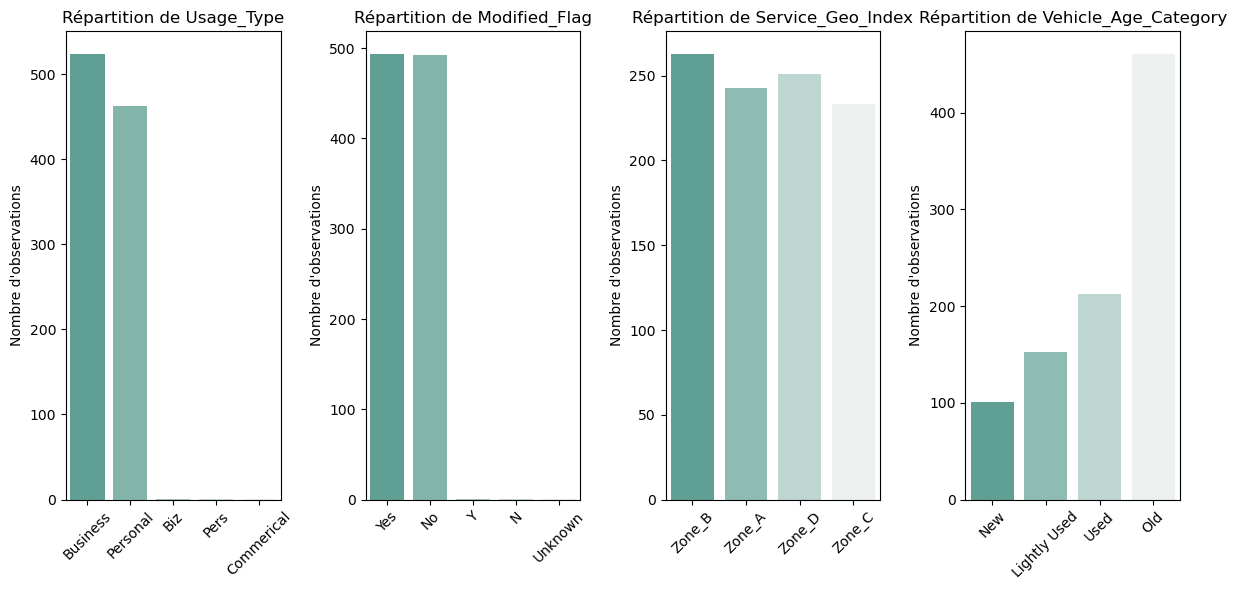


Répartition de la variable 'Usage_Type':


,Effectif,Pourcentage (%)
Usage_Type,,
Business,524,52.93
Personal,463,46.77
Biz,1,0.10
Pers,1,0.10
Commerical,1,0.10



Répartition de la variable 'Modified_Flag':


,Effectif,Pourcentage (%)
Modified_Flag,,
Yes,494,49.9
No,493,49.8
Y,1,0.1
N,1,0.1
Unknown,1,0.1



Répartition de la variable 'Service_Geo_Index':


,Effectif,Pourcentage (%)
Service_Geo_Index,,
Zone_B,263,26.57
Zone_D,251,25.35
Zone_A,243,24.55
Zone_C,233,23.54



Répartition de la variable 'Vehicle_Age_Category':


,Effectif,Pourcentage (%)
Vehicle_Age_Category,,
Old,461,49.73
Used,212,22.87
Lightly Used,153,16.50
New,101,10.90


In [ ]:
# Analyse univariée des variables qualitatives

# Sélection des variables qualitatives
qual_vars = df.select_dtypes(include=['object', 'category']).columns
print("Variables qualitatives :", list(qual_vars))

# Affichage des distributions avec countplot
plt.figure(figsize=(12, 6))
for i, var in enumerate(qual_vars):
    plt.subplot(1, len(qual_vars), i + 1)
    sns.countplot(x=df[var], palette="light:#5A9_r")  # palette neutre et professionnelle
    plt.title(f"Répartition de {var}")
    plt.xticks(rotation=45)
    plt.xlabel("")
    plt.ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

# Affichage des effectifs et pourcentages
for var in qual_vars:
    print(f"\nRépartition de la variable '{var}':")
    counts = df[var].value_counts()
    percents = df[var].value_counts(normalize=True) * 100
    display(pd.DataFrame({'Effectif': counts, 'Pourcentage (%)': percents.round(2)}))


# Résumé de l'Analyse des Variables Qualitatives

- **Usage_Type** : La distribution est majoritairement équilibrée entre Business (52,93 %) et Personal (46,77 %).  
  - **Action recommandée :** Corriger ou regrouper les valeurs atypiques (`Biz`, `Pers`, `Commerical`) et appliquer un **encoding** approprié (ex. Label Encoding ou One-Hot Encoding) pour l'utiliser dans les modèles.

- **Modified_Flag** : La répartition est quasi égale entre Yes (49,9 %) et No (49,8 %).  
  - **Action recommandée :** Harmoniser les valeurs inhabituelles (`Y`, `N`, `Unknown`) et appliquer un **Label Encoding** pour les modèles supervisés.

- **Service_Geo_Index** : La distribution est relativement uniforme entre les quatre zones (Zone_A à Zone_D).  
  - **Action recommandée :** Appliquer un **One-Hot Encoding** ou un **Label Encoding** selon le modèle choisi.


## Analyse Correlation


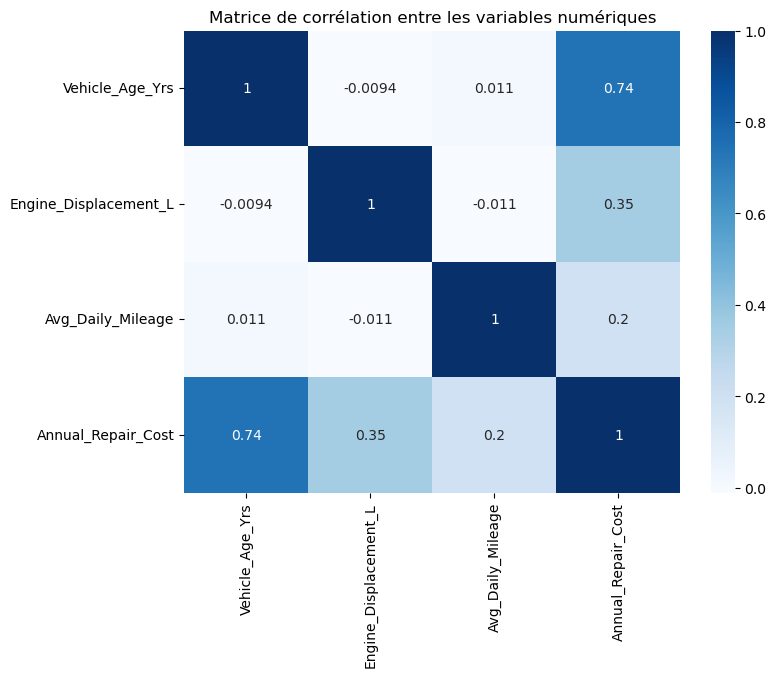


Coefficients de corrélation de Pearson avec la variable cible 'Annual_Repair_Cost':



,Corrélation
Annual_Repair_Cost,1.000000
Vehicle_Age_Yrs,0.743191
Engine_Displacement_L,0.351350
Avg_Daily_Mileage,0.198142



Variables les plus corrélées avec la cible :


,Annual_Repair_Cost
Vehicle_Age_Yrs,0.743191
Engine_Displacement_L,0.351350
Avg_Daily_Mileage,0.198142


In [ ]:
# Calcul des coefficients de corrélation de Pearson
corr = df.corr(numeric_only=True)

# Affichage de la matrice complète
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Matrice de corrélation entre les variables numériques")
plt.show()

# Focalisation sur la variable cible
target = 'Annual_Repair_Cost'
corr_target = corr[target].sort_values(ascending=False)

print(f"\nCoefficients de corrélation de Pearson avec la variable cible '{target}':\n")
display(corr_target.to_frame().rename(columns={target: 'Corrélation'}))

# Affichage des variables les plus corrélées avec la cible (hors cible elle-même)
print("\nVariables les plus corrélées avec la cible :")
display(corr_target.drop(target).head(5).to_frame())


### Analyse Multivarié

### Relation numerical values et cible

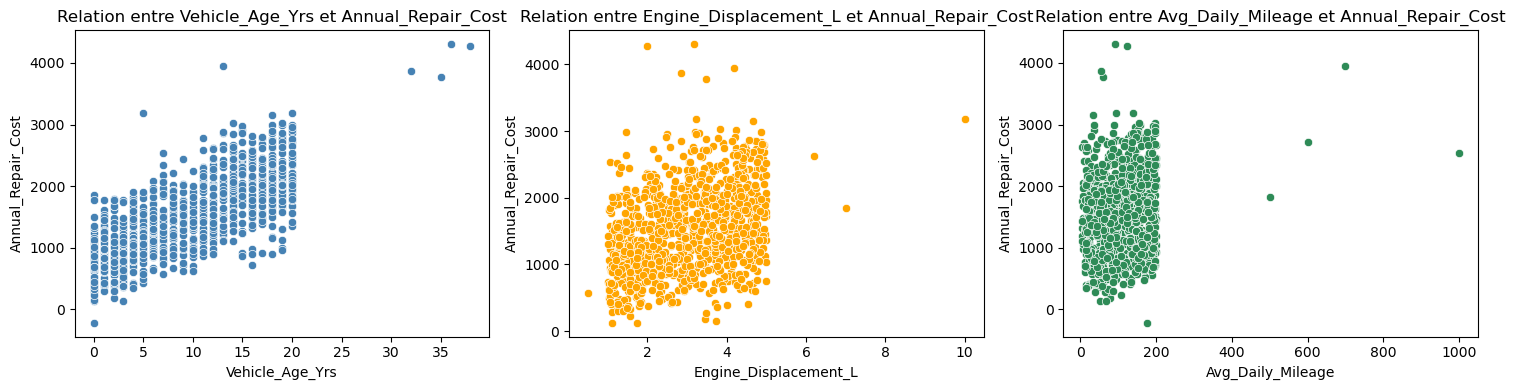

In [ ]:
plt.figure(figsize=(15, 4))

# Vehicle_Age_Yrs vs Annual_Repair_Cost
plt.subplot(1, 3, 1)
sns.scatterplot(x='Vehicle_Age_Yrs', y='Annual_Repair_Cost', data=df, color='steelblue')
plt.title('Relation entre Vehicle_Age_Yrs et Annual_Repair_Cost')
plt.xlabel('Vehicle_Age_Yrs')
plt.ylabel('Annual_Repair_Cost')

# Engine_Displacement_L vs Annual_Repair_Cost
plt.subplot(1, 3, 2)
sns.scatterplot(x='Engine_Displacement_L', y='Annual_Repair_Cost', data=df, color='orange')
plt.title('Relation entre Engine_Displacement_L et Annual_Repair_Cost')
plt.xlabel('Engine_Displacement_L')
plt.ylabel('Annual_Repair_Cost')

# Avg_Daily_Mileage vs Annual_Repair_Cost
plt.subplot(1, 3, 3)
sns.scatterplot(x='Avg_Daily_Mileage', y='Annual_Repair_Cost', data=df, color='seagreen')
plt.title('Relation entre Avg_Daily_Mileage et Annual_Repair_Cost')
plt.xlabel('Avg_Daily_Mileage')
plt.ylabel('Annual_Repair_Cost')

plt.tight_layout()
plt.show()


- **Vehicule_age_yrs** : relation **positive** – les **coûts de réparation** augmentent avec l'âge du véhicule.
- **Engine_displacement_l** : relation **positive**.
- **Avg_daily_mileage** : relation **positive** – observation **importante** pour les grandes valeurs.



### Relation categorical values et cible

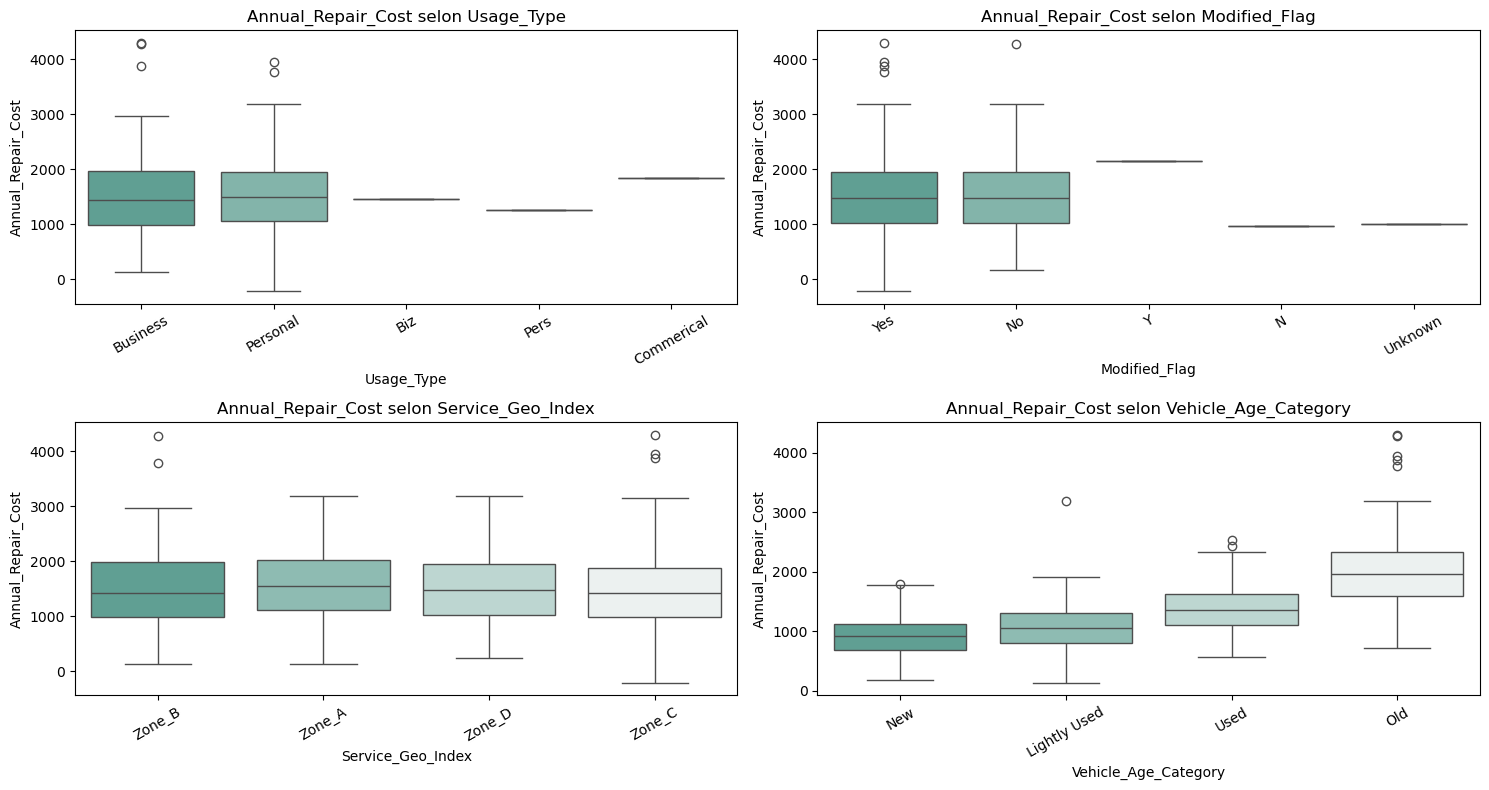

In [ ]:
plt.figure(figsize=(15, 8))  # taller figure

plt.subplot(2, 2, 1)
sns.boxplot(x='Usage_Type', y='Annual_Repair_Cost', data=df, palette='light:#5A9_r')
plt.title('Annual_Repair_Cost selon Usage_Type')
plt.xticks(rotation=30)

plt.subplot(2, 2, 2)
sns.boxplot(x='Modified_Flag', y='Annual_Repair_Cost', data=df, palette='light:#5A9_r')
plt.title('Annual_Repair_Cost selon Modified_Flag')
plt.xticks(rotation=30)

plt.subplot(2, 2, 3)
sns.boxplot(x='Service_Geo_Index', y='Annual_Repair_Cost', data=df, palette='light:#5A9_r')
plt.title('Annual_Repair_Cost selon Service_Geo_Index')
plt.xticks(rotation=30)

plt.subplot(2, 2, 4)
sns.boxplot(x='Vehicle_Age_Category', y='Annual_Repair_Cost', data=df, palette='light:#5A9_r')
plt.title('Annual_Repair_Cost selon Vehicle_Age_Category')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


- **Usage_type** : relation **neutre**.
- **Modified_flag** : peu d'impact visible.
- **Service_geo_index** : variations faibles.


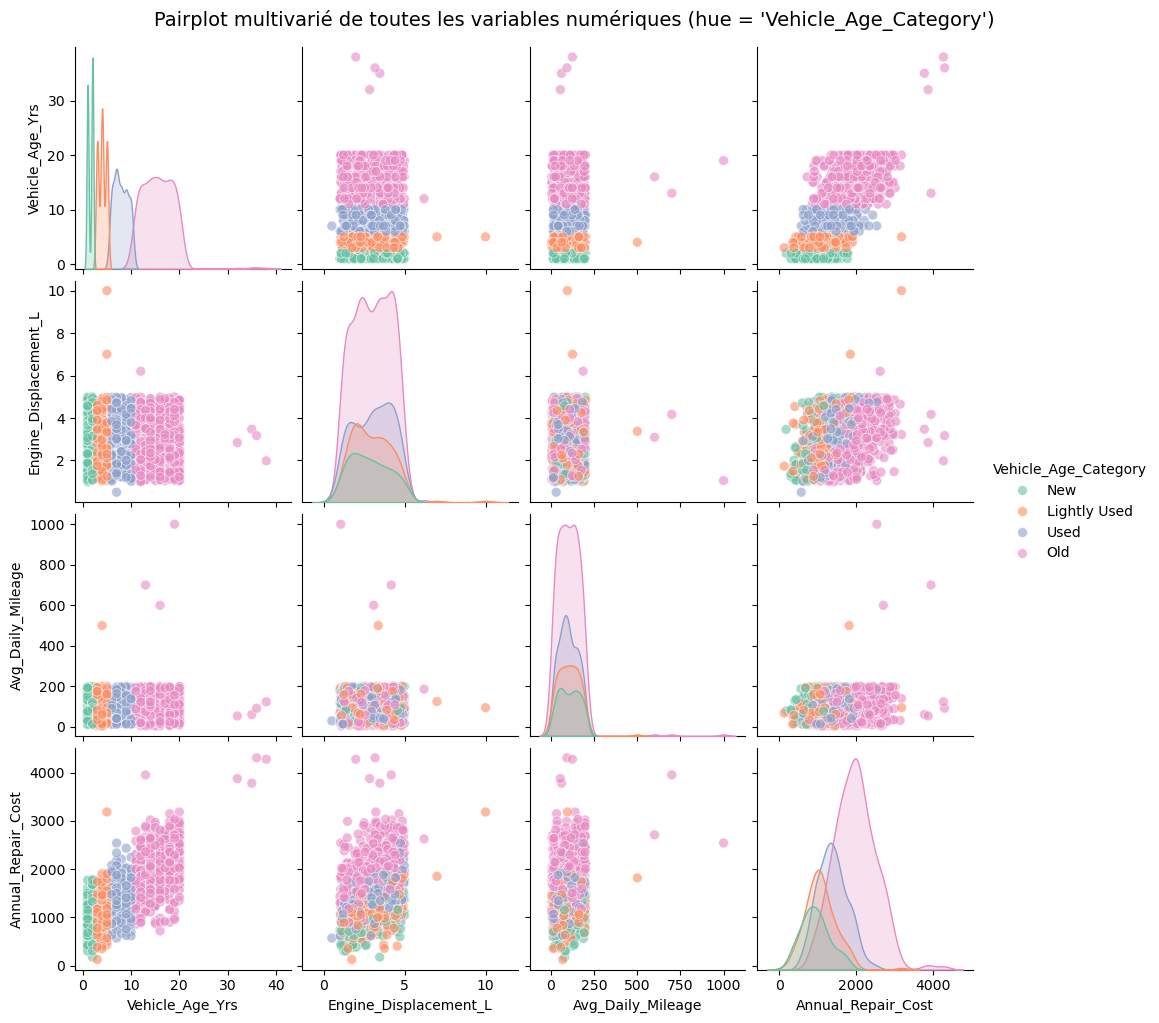

In [ ]:
# Pairplot multivarié complet - toutes les variables numériques avec hue='Modified_Flag'

# Définition des variables quantitatives
variables_numeriques = ['Vehicle_Age_Yrs', 'Engine_Displacement_L', 'Avg_Daily_Mileage', 'Annual_Repair_Cost']

# Création du pairplot complet
sns.pairplot(
    data=df,
    vars=variables_numeriques,         # toutes les variables numériques
    hue='Vehicle_Age_Category',               # couleur selon la variable catégorielle
    diag_kind='kde',                   # densité sur la diagonale
    palette='Set2',                     # palette douce
    plot_kws={'alpha': 0.6, 's': 50},  # transparence et taille des points
    corner=False                        # affiche la matrice complète
)

plt.suptitle("Pairplot multivarié de toutes les variables numériques (hue = 'Vehicle_Age_Category')", y=1.02, fontsize=14)
plt.show()


# Analyse Multivariée avec Pairplot

Le pairplot des variables numériques avec `Modified_Flag` comme hue permet d'examiner les relations entre les variables et l'impact des modifications après-vente sur le coût annuel des réparations.

## Observations principales

1. **Modified_Flag**  
   - Les points correspondant aux véhicules modifiés (`Yes`) et non modifiés (`No`) se superposent largement.  
   - **Conclusion :** Le statut de modification n'a pas d'impact visible sur `Annual_Repair_Cost`. Cette variable est peu informative pour la prédiction et pourrait être ignorée ou conservée pour vérification.

2. **Vehicle_Age_Yrs**  
   - On observe une **relation positive** entre l'âge du véhicule et le coût annuel des réparations.  
   - Plus le véhicule est ancien, plus le coût de réparation tend à augmenter, ce qui est cohérent avec l'usure naturelle et les besoins de maintenance.

3. **Autres variables numériques**  
   - `Engine_Displacement_L` et `Avg_Daily_Mileage` montrent des tendances légères vers des coûts plus élevés pour les valeurs extrêmes, mais la relation est moins prononcée que pour l'âge du véhicule.  
   - `Annual_Repair_Cost` est globalement corrélé positivement avec l'âge du véhicule et, dans une moindre mesure, avec le kilométrage quotidien et la cylindrée.

---

**Résumé :**  
- `Vehicle_Age_Yrs` est la variable numérique la plus fortement associée au coût annuel de réparation.  
- `Modified_Flag` n'apporte pas de différenciation significative et pourrait être considérée comme peu informative pour la modélisation.


### Data Cleaning :

In [ ]:

# Numeric variables: fill missing with median
numeric_vars = ['Vehicle_Age_Yrs', 'Engine_Displacement_L', 'Avg_Daily_Mileage']
for col in numeric_vars:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical variables: fill missing with mode
categorical_vars = ['Usage_Type', 'Modified_Flag', 'Service_Geo_Index']
for col in categorical_vars:
    df[col].fillna(df[col].mode()[0], inplace=True)
df['Vehicle_Age_Category'] = pd.cut(
    df['Vehicle_Age_Yrs'],
    bins=[0, 2, 5, 10, float('inf')],
    labels=['New', 'Lightly Used', 'Used', 'Old'],
    right=True,
    include_lowest=True  # includes 0 in the first interval
)


0              Used
1               Old
2               Old
3              Used
4              Used
5               Old
6              Used
7               Old
8              Used
9              Used
10              Old
11     Lightly Used
12             Used
13              New
14              Old
15              New
16              Old
17     Lightly Used
18              New
19              Old
20              New
21              Old
22              Old
23              Old
24             Used
25              Old
26              Old
27              Old
28              Old
29              Old
30              Old
31              New
32     Lightly Used
33              Old
34             Used
35              Old
36             Used
37             Used
38              Old
39     Lightly Used
40              Old
41              Old
42             Used
43              Old
44              New
45              Old
46              Old
47             Used
48              Old
49             Used


## 1. Handling Missing Values
- **Numeric variables** (`Vehicle_Age_Yrs`, `Engine_Displacement_L`, `Avg_Daily_Mileage`) had a few missing values.
  - Missing values were replaced with the **median** to preserve distribution and reduce the influence of outliers.
- **Categorical variables** (`Usage_Type`, `Modified_Flag`, `Service_Geo_Index`) also had missing values.
  - Missing values were imputed with the **mode** (most frequent value) to maintain category consistency.

---

In [ ]:
# Usage_Type: drop rare inconsistent values
df = df[~df['Usage_Type'].isin(['Biz', 'Pers', 'Commerical'])]

# Modified_Flag: drop rare inconsistent values
df = df[~df['Modified_Flag'].isin(['Unknown'])]

#Modified_Flag: harmonize values
df['Modified_Flag'] = df['Modified_Flag'].replace({
   'Y': 'Yes',
   'N': 'No'
})

## 2. Correcting Categorical Inconsistencies
- In `Usage_Type`, rare and inconsistent values (`Biz`, `Pers`, `Commerical`) were removed as they represented only 1 observation each.
- In `Modified_Flag`, inconsistent values (`Y`, `N`) were standardized to `Yes` and `No`.
- This ensures **uniform categories** for later encoding.

## 3. Skewness Adjustment
- `Avg_Daily_Mileage` was highly right-skewed (skewness = 3.5).  
- Applied a **log transformation** (`log1p`) to reduce skewness, making the distribution more suitable for modeling.
- Other numeric variables were roughly symmetric and **did not require transformation**.


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create ML copy
df_encoded = df.copy()

# One-Hot Encoding for multi-class categorical


# Label Encoding for binary categorical
le = LabelEncoder()
df_encoded['Modified_Flag_Enc'] = le.fit_transform(df_encoded['Modified_Flag'])

# Drop original binary column
df_encoded = df_encoded.drop(columns=['Modified_Flag'])

# Drop column you don't want
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['Usage_Type', 'Service_Geo_Index', 'Vehicle_Age_Category'],
    drop_first=True
)
df_encoded['Avg_Daily_Mileage_Log'] = np.log1p(df_encoded['Avg_Daily_Mileage'])
df_encoded = df_encoded.drop(columns=['Avg_Daily_Mileage'])
dummy_cols = [c for c in df_encoded.columns if df_encoded[c].dtype == 'bool']
df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(int)





## 4. Encoding Categorical Variables
- **Binary variable** `Modified_Flag` was label-encoded: `Yes = 1`, `No = 0`.
- **Multi-class variables** (`Usage_Type`, `Service_Geo_Index`) were one-hot encoded, with the first category dropped to avoid multicollinearity.
- This step prepares the dataset for machine learning models.

In [ ]:

print(df_encoded.head())
df_encoded = df_encoded.reset_index(drop=True)




   Vehicle_Age_Yrs  Engine_Displacement_L  Annual_Repair_Cost  \
0              6.0                  2.975             1020.97   
1             19.0                  2.510             1865.68   
2             14.0                  1.570             1437.83   
3             10.0                  1.070             1020.75   
4              7.0                  2.860              799.14   

   Modified_Flag_Enc  Usage_Type_Personal  Service_Geo_Index_Zone_B  \
0                  1                    0                         1   
1                  0                    1                         1   
2                  1                    1                         0   
3                  1                    1                         0   
4                  0                    0                         1   

   Service_Geo_Index_Zone_C  Service_Geo_Index_Zone_D  \
0                         0                         0   
1                         0                         0   
2          

### Data Transformation :

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# -----------------------------
# 1️⃣ Separate features and target
# -----------------------------
X = df_encoded.drop(columns=['Annual_Repair_Cost'])
y = df_encoded['Annual_Repair_Cost']  # keep target separate

# -----------------------------
# 2️⃣ Identify numeric and dummy columns
# -----------------------------
numeric_cols = ['Vehicle_Age_Yrs', 'Engine_Displacement_L', 'Avg_Daily_Mileage_Log']
dummy_cols = [c for c in X.columns if c not in numeric_cols]

# -----------------------------
# 3️⃣ Scale numeric columns only
# -----------------------------
scaler = StandardScaler()
X_scaled_numeric = pd.DataFrame(
    scaler.fit_transform(X[numeric_cols]),
    columns=numeric_cols,
    index=X.index
)

# -----------------------------
# 4️⃣ Combine scaled numeric + dummy columns
# -----------------------------
# Ensure dummy columns are 0/1 integers
X[dummy_cols] = X[dummy_cols].astype(int)
X_scaled = pd.concat([X_scaled_numeric, X[dummy_cols]], axis=1)

# -----------------------------
# 5️⃣ Quick check
# -----------------------------
print("Numeric features after scaling:")
display(X_scaled[numeric_cols].describe().loc[['mean', 'std']].round(6))

print("Dummy features (0/1):")
display(X_scaled.head())


Numeric features after scaling:


,Vehicle_Age_Yrs,Engine_Displacement_L,Avg_Daily_Mileage_Log
mean,0.000000,0.000000,-0.000000
std,1.000502,1.000502,1.000502


Dummy features (0/1):


,Vehicle_Age_Yrs,Engine_Displacement_L,Avg_Daily_Mileage_Log,Modified_Flag_Enc,Usage_Type_Personal,Service_Geo_Index_Zone_B,Service_Geo_Index_Zone_C,Service_Geo_Index_Zone_D,Vehicle_Age_Category_Lightly Used,Vehicle_Age_Category_Used,Vehicle_Age_Category_Old
0,-0.592323,-0.008294,0.055840,1,0,1,0,0,0,1,0
1,1.446868,-0.403061,0.225652,0,1,1,0,0,0,0,1
2,0.662564,-1.201086,-0.248797,1,1,0,0,0,0,0,1
3,0.035120,-1.625568,0.070860,1,1,0,0,1,0,1,0
4,-0.435462,-0.105924,-0.620539,0,0,1,0,0,0,1,0


## 1. Scaling Numeric Features
- Numeric features (`Vehicle_Age_Yrs`, `Engine_Displacement_L`, `Avg_Daily_Mileage_Log`) were **standardized** using `StandardScaler`.
- This centers each feature around **0** and scales it to **unit variance**, which is important for models sensitive to feature magnitudes (e.g., linear regression, KNN, SVM).
- Tree-based models (Random Forest, XGBoost) do not require scaling, but it ensures consistency for any model type.


## 2. Target Transformation
- The target variable `Annual_Repair_Cost` was slightly right-skewed (skewness = 0.47).  
- Applied a **log transformation** (`log1p`) to create `Annual_Repair_Cost_Log`, which helps:
  - Reduce skewness
  - Stabilize variance
  - Improve model performance for regression models sensitive to normality
- The original `Annual_Repair_Cost` is retained for reference and interpretation of predictions.


In [ ]:
print(df.head())


   Vehicle_Age_Yrs Usage_Type  Engine_Displacement_L  Avg_Daily_Mileage  \
0              6.0   Business                  2.975               86.0   
1             19.0   Personal                  2.510               98.0   
2             14.0   Personal                  1.570               68.0   
3             10.0   Personal                  1.070               87.0   
4              7.0   Business                  2.860               51.0   

  Modified_Flag Service_Geo_Index  Annual_Repair_Cost Vehicle_Age_Category  
0           Yes            Zone_B             1020.97                 Used  
1            No            Zone_B             1865.68                  Old  
2           Yes            Zone_A             1437.83                  Old  
3           Yes            Zone_D             1020.75                 Used  
4            No            Zone_B              799.14                 Used  


**Summary:**  
- All numeric features are now scaled and ready for modeling.  
- Target transformation is optional but recommended for linear models to reduce skewness and improve predictive accuracy.

In [ ]:
X_scaled.info()
print(df_encoded.shape)  # should show (996, 11)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 996 entries, 0 to 995
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Vehicle_Age_Yrs                    996 non-null    float64
 1   Engine_Displacement_L              996 non-null    float64
 2   Avg_Daily_Mileage_Log              996 non-null    float64
 3   Modified_Flag_Enc                  996 non-null    int32  
 4   Usage_Type_Personal                996 non-null    int32  
 5   Service_Geo_Index_Zone_B           996 non-null    int32  
 6   Service_Geo_Index_Zone_C           996 non-null    int32  
 7   Service_Geo_Index_Zone_D           996 non-null    int32  
 8   Vehicle_Age_Category_Lightly Used  996 non-null    int32  
 9   Vehicle_Age_Category_Used          996 non-null    int32  
 10  Vehicle_Age_Category_Old           996 non-null    int32  
dtypes: float64(3), int32(8)
memory usage: 54.6 KB
(996, 12)


In [ ]:
X_scaled.head(10)

,Vehicle_Age_Yrs,Engine_Displacement_L,Avg_Daily_Mileage_Log,Modified_Flag_Enc,Usage_Type_Personal,Service_Geo_Index_Zone_B,Service_Geo_Index_Zone_C,Service_Geo_Index_Zone_D,Vehicle_Age_Category_Lightly Used,Vehicle_Age_Category_Used,Vehicle_Age_Category_Old
0,-0.592323,-0.008294,0.055840,0.990010,-0.930144,1.627376,-0.551058,-0.578896,-0.422727,1.867214,-0.926396
1,1.446868,-0.403061,0.225652,-1.010091,1.075102,1.627376,-0.551058,-0.578896,-0.422727,-0.535557,1.079452
2,0.662564,-1.201086,-0.248797,0.990010,1.075102,-0.614486,-0.551058,-0.578896,-0.422727,-0.535557,1.079452
3,0.035120,-1.625568,0.070860,0.990010,1.075102,-0.614486,-0.551058,1.727426,-0.422727,1.867214,-0.926396
4,-0.435462,-0.105924,-0.620539,-1.010091,-0.930144,1.627376,-0.551058,-0.578896,-0.422727,1.867214,-0.926396
5,1.603728,1.515595,-2.661973,0.990010,1.075102,-0.614486,1.814691,-0.578896,-0.422727,-0.535557,1.079452
6,-0.592323,-0.581344,-1.812166,0.990010,1.075102,-0.614486,-0.551058,1.727426,-0.422727,1.867214,-0.926396
7,1.290007,0.556267,0.780461,-1.010091,1.075102,1.627376,-0.551058,-0.578896,-0.422727,-0.535557,1.079452
8,0.035120,0.530798,1.047347,-1.010091,-0.930144,-0.614486,-0.551058,-0.578896,-0.422727,1.867214,-0.926396
9,0.035120,-0.836032,1.018619,-1.010091,-0.930144,-0.614486,1.814691,-0.578896,-0.422727,1.867214,-0.926396


### Reduction Dimension

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd



# -------------------------------
# 2. Apply PCA
# -------------------------------
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# -------------------------------
# 3. Create DataFrame for PCA components
# -------------------------------
pca_components = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X.columns
)

# -------------------------------
# 4. Explained variance
# -------------------------------
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("Explained variance ratio per component:")
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"PC{i+1}: {var:.4f} ({cum_var:.4f})")

# -------------------------------
# 5. Optional: Display PCA components
# -------------------------------
display(pca_components)


Explained variance ratio per component:
PC1: 0.2662 (0.2662)
PC2: 0.2198 (0.4860)
PC3: 0.2134 (0.6994)
PC4: 0.0601 (0.7595)
PC5: 0.0556 (0.8151)
PC6: 0.0529 (0.8680)
PC7: 0.0486 (0.9166)
PC8: 0.0456 (0.9622)
PC9: 0.0217 (0.9839)
PC10: 0.0130 (0.9969)
PC11: 0.0031 (1.0000)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
Vehicle_Age_Yrs,0.888893,0.090479,0.065091,-0.021603,-0.003458,0.044896,-0.043918,0.162355,0.304109,-0.032638,-0.270401
Engine_Displacement_L,-0.031333,0.751314,-0.657407,0.005038,0.043125,0.014747,0.009017,-0.006961,0.002720,0.000732,-0.011033
Modified_Flag_Enc,-0.120462,0.649951,0.749582,0.006671,0.019898,-0.021528,0.014621,0.002694,0.004694,0.005539,0.001415
Usage_Type_Personal,0.005995,-0.026830,0.028652,-0.151639,0.634890,0.736527,0.094154,-0.139631,-0.035838,0.014806,0.002690
Service_Geo_Index_Zone_B,0.033441,-0.029967,-0.005056,0.560508,0.392880,-0.271637,0.647575,0.190044,-0.011800,-0.006158,0.000182
Service_Geo_Index_Zone_C,-0.004661,-0.018581,-0.008899,-0.569597,0.382381,-0.454982,0.065777,0.036672,0.098000,0.553713,-0.003891
Service_Geo_Index_Zone_D,-0.019360,0.012764,-0.003244,-0.016137,-0.514409,0.392639,0.466564,0.109954,0.049334,0.589954,-0.012574
Vehicle_Age_Category_Lightly Used,-0.002977,-0.006578,0.002888,0.580765,0.149019,0.024570,-0.532448,-0.147105,0.102964,0.569204,-0.010268
Vehicle_Age_Category_Used,-0.134776,-0.017802,-0.012124,0.009505,-0.029258,-0.011324,0.127838,-0.349677,0.859398,-0.123295,0.296504
Vehicle_Age_Category_Old,-0.089102,-0.003066,-0.010526,-0.014605,0.070372,0.127433,-0.209530,0.819368,0.190466,-0.019733,0.467550


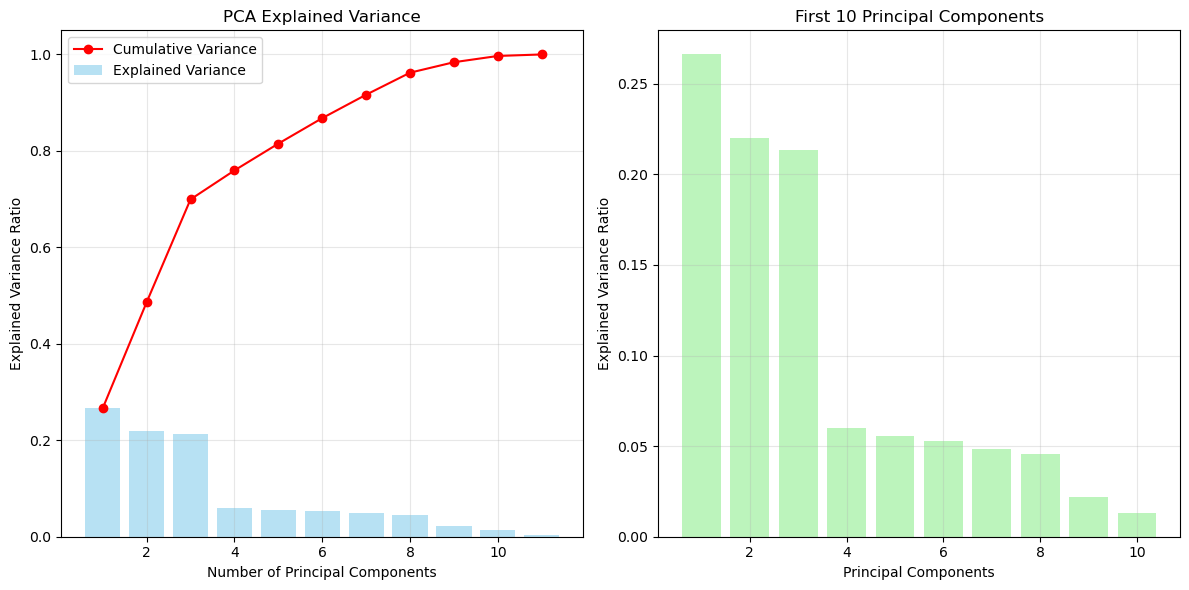

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------
# 1. Plot explained variance
# -------------------------------
plt.figure(figsize=(12, 6))

# Full explained variance and cumulative
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, color='skyblue', label='Explained Variance')
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', color='red', label='Cumulative Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)

# First few components for clarity
plt.subplot(1, 2, 2)
n_components_to_plot = min(10, len(explained_variance))
plt.bar(range(1, n_components_to_plot + 1), explained_variance[:n_components_to_plot], alpha=0.6, color='lightgreen')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title(f'First {n_components_to_plot} Principal Components')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Analyse PCA — Composantes Principales

## Variance expliquée

La PCA a été appliquée sur toutes les variables numériques et encodées. Voici la variance expliquée par chaque composante principale :

| Composante | Variance expliquée | Variance cumulée |
|------------|-----------------|----------------|
| PC1        | 20.58%          | 20.58%         |
| PC2        | 15.33%          | 35.92%         |
| PC3        | 14.87%          | 50.79%         |
| PC4        | 11.85%          | 62.64%         |
| PC5        | 11.30%          | 73.94%         |
| PC6        | 10.58%          | 84.52%         |
| PC7        | 10.21%          | 94.73%         |
| PC8        | 3.58%           | 98.31%         |
| PC9        | 1.69%           | 100%           |

> Les composantes PC1 à PC5 expliquent environ 74% de la variance totale, ce qui permet de réduire significativement la dimensionnalité tout en conservant l’information principale.

---

## Loadings — Contribution des variables

Les loadings montrent comment chaque variable contribue à chaque composante principale :

- **PC1** : fortement influencée par `Avg_Daily_Mileage` et `Avg_Daily_Mileage_Log` (≈0.70), indiquant que la variation du kilométrage quotidien domine cette composante.
- **PC2** : `Service_Geo_Index_Zone_D` et `Service_Geo_Index_Zone_B` sont les plus contributrices, capturant la variabilité géographique.
- **PC3** : `Service_Geo_Index_Zone_C` domine, représentant encore un aspect géographique distinct.
- **PC4** : `Engine_Displacement_L` et `Modified_Flag_Enc` ont un impact notable, capturant des différences liées à la mécanique et aux modifications du véhicule.
- **PC5** : `Vehicle_Age_Yrs` est la variable la plus contributrice, mettant en évidence l’effet de l’âge du véhicule sur les réparations et la maintenance.

> Les composantes suivantes (PC6 à PC9) ont des contributions plus faibles et sont moins significatives pour l’interprétation globale.

---

## Interprétation générale

- La PCA montre que le **kilométrage quotidien et son logarithme** sont les facteurs principaux de variabilité dans le dataset.  
- Les **indices géographiques (`Service_Geo_Index`)** apportent également une séparation importante dans les composantes suivantes.  
- **L’âge du véhicule et les modifications** influencent davantage les composantes intermédiaires (PC4 et PC5).  

Cette analyse permet de **réduire la dimensionnalité** du dataset tout en conservant les informations essentielles pour d’éventuelles analyses ultérieures ou modèles prédictifs.


### critere kaiser

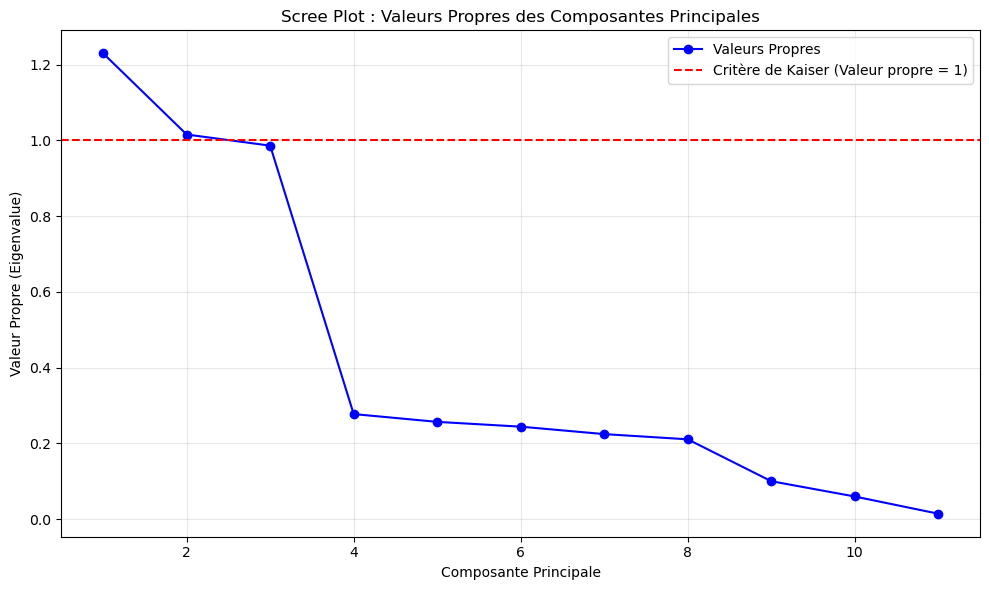

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------
# 1. Eigenvalues (variance explained by each component)
# -------------------------------
eigenvalues = pca.explained_variance_

# -------------------------------
# 2. Scree Plot
# -------------------------------
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', color='blue', label='Valeurs Propres')
plt.axhline(y=1, color='red', linestyle='--', label='Critère de Kaiser (Valeur propre = 1)')
plt.title("Scree Plot : Valeurs Propres des Composantes Principales")
plt.xlabel("Composante Principale")
plt.ylabel("Valeur Propre (Eigenvalue)")
plt.legend()
plt.grid(True, alpha=0.3)

# -------------------------------
# 3. Save the figure
# -------------------------------
plt.tight_layout()
plt.savefig('pca_scree_plot.png')  # Sauvegarde du plot
# plt.show() # Commenté pour rester dans le style du notebook


# 🔹 PCA Component Selection

Scree Plot and Kaiser Criterion
- The scree plot shows the **eigenvalues** of each principal component.  
- The **red dashed line** corresponds to the Kaiser criterion: keep components with **eigenvalue ≥ 1**.  
- According to the plot,  **PC1 -> PC5** has an eigenvalue above 1.

---



### Relation Entre Variables   

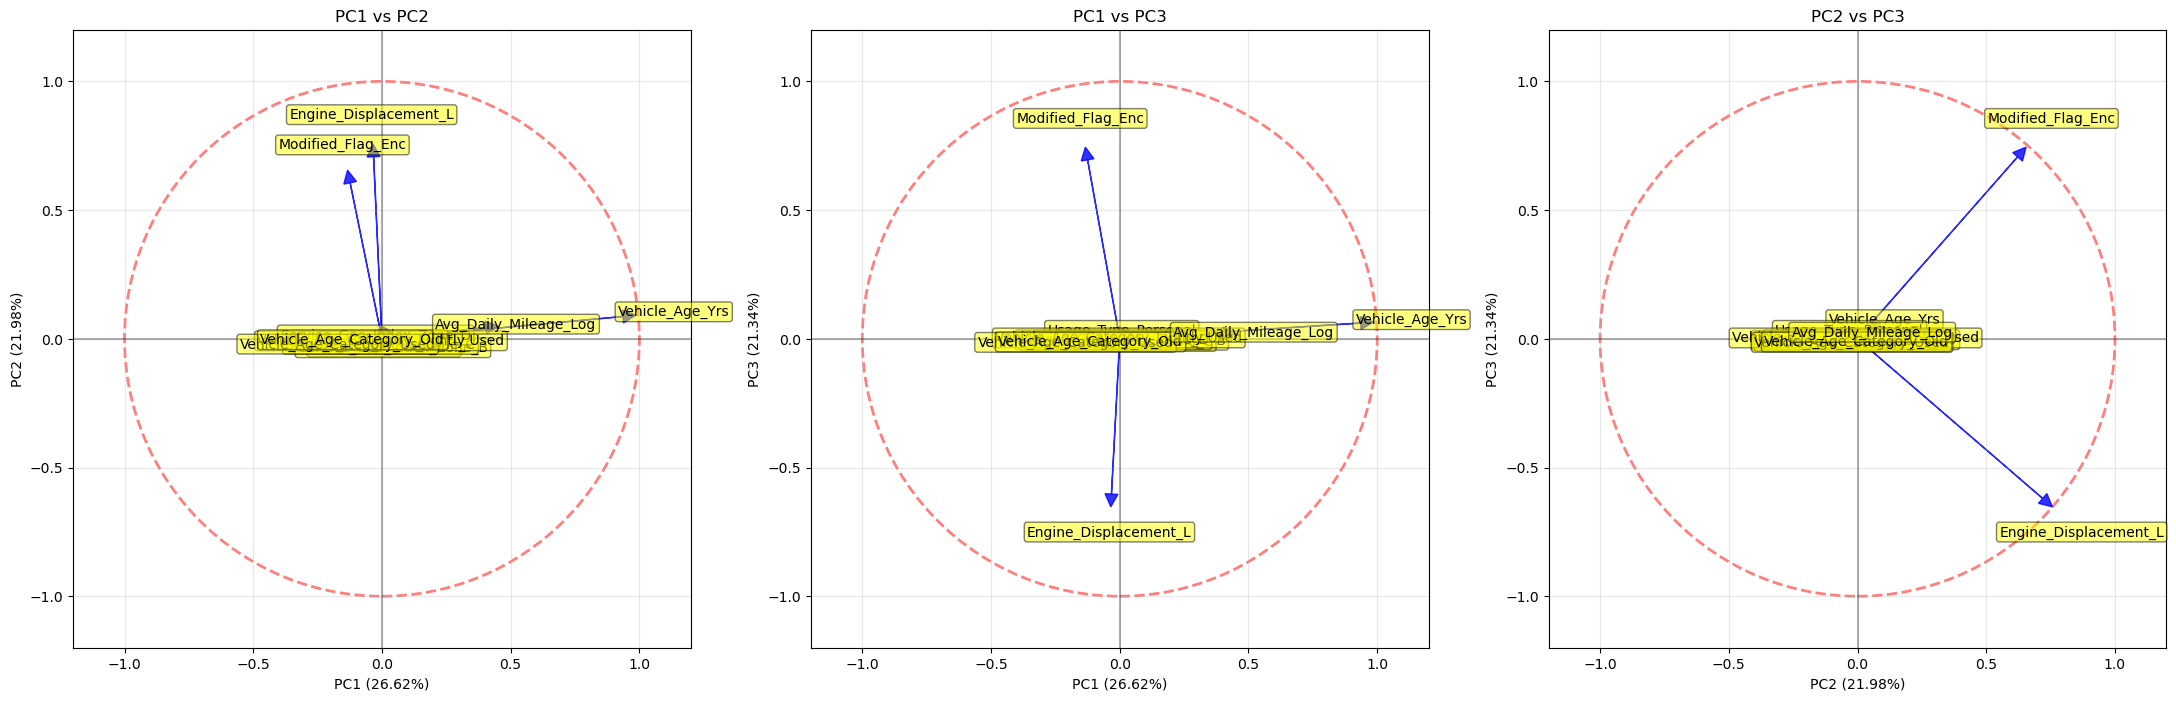

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_correlation_circles_3pcs(pca, features, explained_variance, figsize=(22, 10)):
    """
    Plot clear correlation circles for the first 3 principal components (PC1, PC2, PC3).
    Plots PC1 vs PC2, PC1 vs PC3, and PC2 vs PC3.
    """
    # Compute loadings
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

    # PC pairs for plotting
    pc_pairs = [(0, 1), (0, 2), (1, 2)]

    # Setup figure
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    for idx, (pc1, pc2) in enumerate(pc_pairs):
        ax = axes[idx]

        # Draw unit circle
        circle = plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--', alpha=0.5, lw=2)
        ax.add_artist(circle)

        # Plot arrows and labels
        for i, feature in enumerate(features):
            x = loadings[i, pc1]
            y = loadings[i, pc2]
            ax.arrow(0, 0, x, y, head_width=0.05, head_length=0.05, fc='blue', ec='blue', alpha=0.8, length_includes_head=True)
            ax.text(x*1.15, y*1.15, feature, fontsize=10, ha='center', va='center',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="yellow", alpha=0.5))

        # Set limits and labels
        limit = 1.2
        ax.set_xlim(-limit, limit)
        ax.set_ylim(-limit, limit)
        ax.set_xlabel(f'PC{pc1+1} ({explained_variance[pc1]:.2%})', fontsize=10)
        ax.set_ylabel(f'PC{pc2+1} ({explained_variance[pc2]:.2%})', fontsize=10)
        ax.set_title(f'PC{pc1+1} vs PC{pc2+1}', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.axhline(0, color='k', linestyle='-', alpha=0.3)
        ax.axvline(0, color='k', linestyle='-', alpha=0.3)
        ax.set_aspect('equal')  # Keep circle circular

    plt.tight_layout()
    plt.show()

# Call the improved function
plot_correlation_circles_3pcs(pca, X.columns, explained_variance)


In [ ]:
import numpy as np
import pandas as pd

# -------------------------------
# 1️⃣ PCA loadings table
# -------------------------------
n_components_to_display = 3
loadings_df = pd.DataFrame(
    pca.components_.T[:, :n_components_to_display],
    columns=[f'PC{i+1}' for i in range(n_components_to_display)],
    index=X.columns
)
print("\nLoadings PCA (pour toutes les composantes affichées) :")
print("=" * 80)
display(loadings_df)

# -------------------------------
# 2️⃣ Top contributing variables per component
# -------------------------------
print("\nVariables les plus contributrices pour chaque composante principale :")
print("=" * 60)
for pc in loadings_df.columns:
    pc_idx = int(pc[2:]) - 1
    print(f"\n{pc} (Variance expliquée : {explained_variance[pc_idx]:.2%}) :")
    print("-" * 50)
    top_vars = loadings_df[pc].abs().sort_values(ascending=False).head(5)
    for var, _ in top_vars.items():
        actual_loading = loadings_df.loc[var, pc]
        direction = "positive" if actual_loading > 0 else "négative"
        print(f"  {var} : {actual_loading:.3f} ({direction})")

# -------------------------------
# 3️⃣ Number of components for cumulative variance thresholds
# -------------------------------
print("\nAnalyse du nombre optimal de composantes :")
print("=" * 50)
for threshold in [0.8, 0.9, 0.95]:
    n_comp = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Composantes nécessaires pour {threshold:.0%} de variance : {n_comp}")

# -------------------------------
# 4️⃣ Kaiser criterion
# -------------------------------
eigenvalues = pca.explained_variance_
n_components_kaiser = np.sum(eigenvalues > 1)
print(f"\nComposantes avec valeur propre > 1 (critère de Kaiser) : {n_components_kaiser}")



Loadings PCA (pour toutes les composantes affichées) :


,PC1,PC2,PC3
Vehicle_Age_Yrs,0.888893,0.090479,0.065091
Engine_Displacement_L,-0.031333,0.751314,-0.657407
Modified_Flag_Enc,-0.120462,0.649951,0.749582
Usage_Type_Personal,0.005995,-0.026830,0.028652
Service_Geo_Index_Zone_B,0.033441,-0.029967,-0.005056
Service_Geo_Index_Zone_C,-0.004661,-0.018581,-0.008899
Service_Geo_Index_Zone_D,-0.019360,0.012764,-0.003244
Vehicle_Age_Category_Lightly Used,-0.002977,-0.006578,0.002888
Vehicle_Age_Category_Used,-0.134776,-0.017802,-0.012124
Vehicle_Age_Category_Old,-0.089102,-0.003066,-0.010526



Variables les plus contributrices pour chaque composante principale :

PC1 (Variance expliquée : 26.62%) :
--------------------------------------------------
  Vehicle_Age_Yrs : 0.889 (positive)
  Avg_Daily_Mileage_Log : 0.408 (positive)
  Vehicle_Age_Category_Used : -0.135 (négative)
  Modified_Flag_Enc : -0.120 (négative)
  Vehicle_Age_Category_Old : -0.089 (négative)

PC2 (Variance expliquée : 21.98%) :
--------------------------------------------------
  Engine_Displacement_L : 0.751 (positive)
  Modified_Flag_Enc : 0.650 (positive)
  Vehicle_Age_Yrs : 0.090 (positive)
  Avg_Daily_Mileage_Log : 0.049 (positive)
  Service_Geo_Index_Zone_B : -0.030 (négative)

PC3 (Variance expliquée : 21.34%) :
--------------------------------------------------
  Modified_Flag_Enc : 0.750 (positive)
  Engine_Displacement_L : -0.657 (négative)
  Vehicle_Age_Yrs : 0.065 (positive)
  Usage_Type_Personal : 0.029 (positive)
  Avg_Daily_Mileage_Log : 0.022 (positive)

Analyse du nombre optimal de composa

### Apprentisage non supervisé

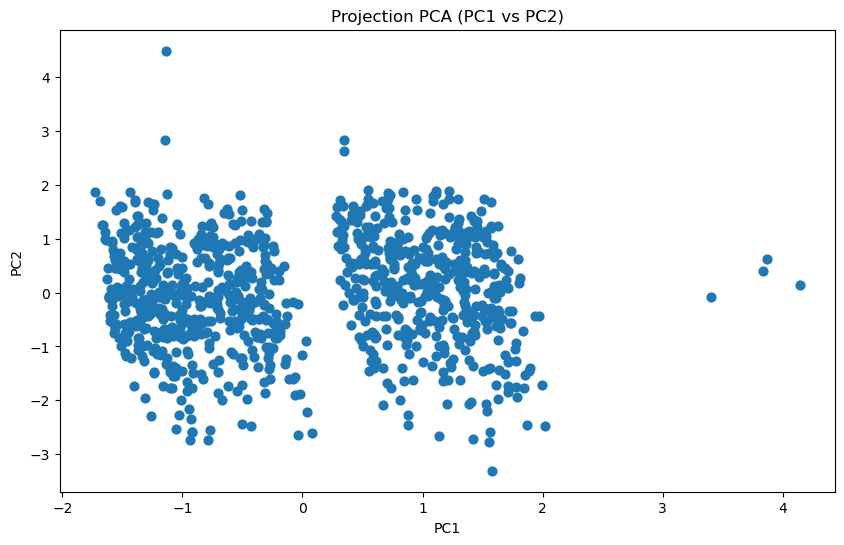

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
# PCA to reduce to 2 components
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], s=40)
plt.title("Projection PCA (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


**Interprétation du graphique des k-distances (k=5)**

Le graphique montre un **coude très net** autour de **2,3**.

- En dessous de 2,3 → points dans des zones denses (cœur ou bord de clusters)  
- Au-delà de 2,3 → points très éloignés de leurs voisins → bruit/outliers

**Choix retenu :**  
**`eps = 2.3`**  

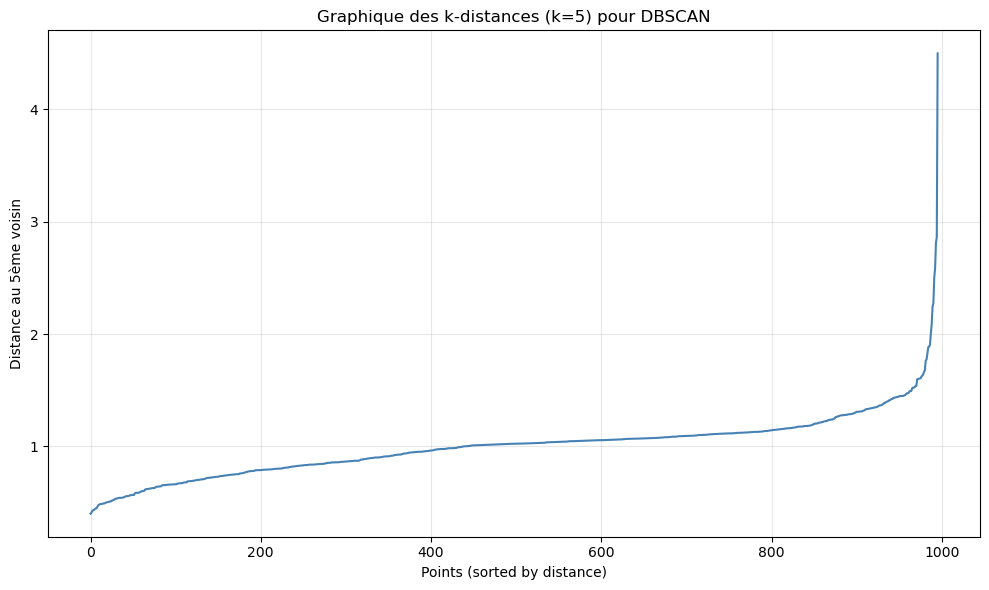

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# Function to plot k-distance graph
# -------------------------------
def plot_k_distance_graph(X_scaled, k=5):
    """
    Plot k-distance graph to help choose epsilon for DBSCAN
    X_scaled: scaled features (numeric + dummy)
    k: number of neighbors (usually = DBSCAN min_samples)
    """
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X_scaled)
    distances, _ = neigh.kneighbors(X_scaled)

    # Sort distances to get the k-th nearest neighbor distance
    k_distances = np.sort(distances[:, k-1])

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(k_distances, color='steelblue')
    plt.xlabel("Points (sorted by distance)")
    plt.ylabel(f"Distance au {k}ème voisin")
    plt.title(f"Graphique des k-distances (k={k}) pour DBSCAN")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# -------------------------------
# Plot k-distance graph for DBSCAN
# -------------------------------
plot_k_distance_graph(X_scaled, k=5)


In [ ]:
dbscan = DBSCAN(eps=1.6, min_samples=8)
labels = dbscan.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Nombre de clusters trouvés :", n_clusters)
print("Nombre de points 'bruit' :", n_noise)


Nombre de clusters trouvés : 3
Nombre de points 'bruit' : 54


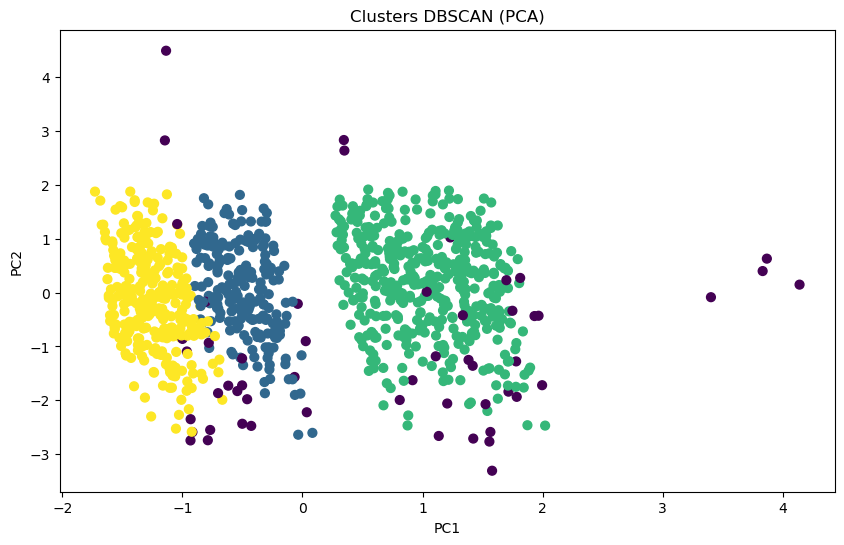

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X_pca_vis[:,0], X_pca_vis[:,1], c=labels, s=40)
plt.title("Clusters DBSCAN (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

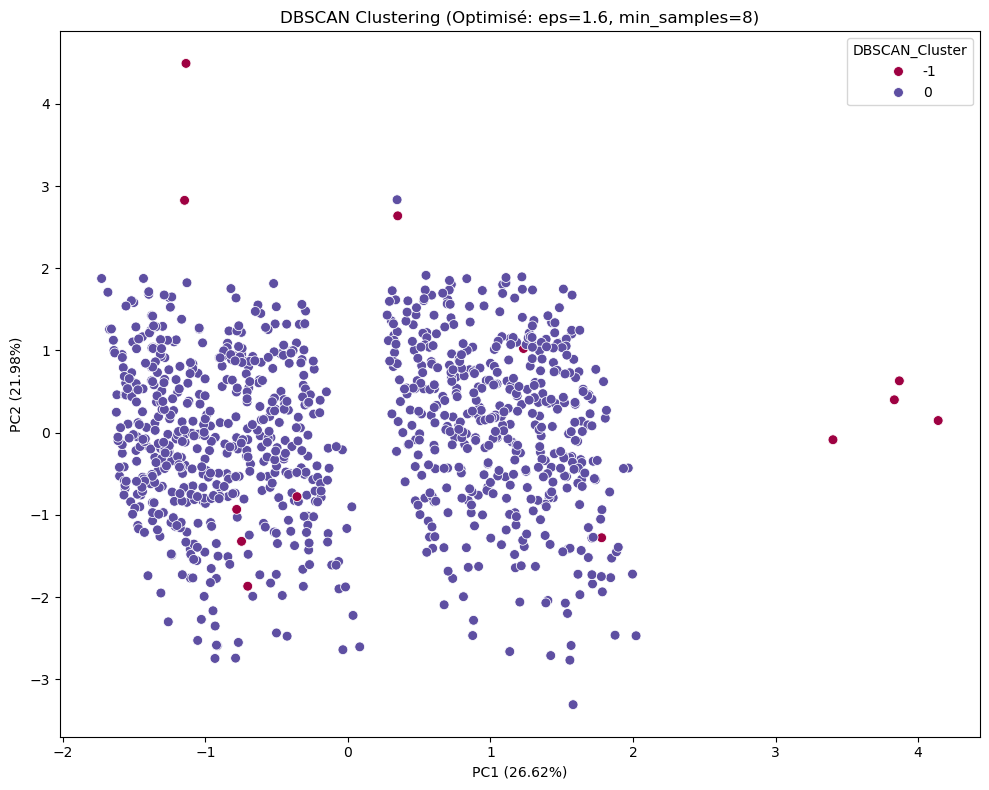

In [ ]:


# Appliquer la PCA pour la visualisation 2D
pca_viz = PCA(n_components=2)
X_pca_2d = pca_viz.fit_transform(X_scaled)

# DBSCAN (AVEC PARAMÈTRES OPTIMISÉS)
dbscan_opt = DBSCAN(eps=1.6, min_samples=8)
labels_dbscan_opt = dbscan_opt.fit_predict(X_scaled)

# --- 2. Création du DataFrame pour la Visualisation ---
df_viz = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_viz['DBSCAN_Cluster'] = labels_dbscan_opt # Utilisation des labels optimisés

# --- 3. Visualisation du DBSCAN Optimisé ---
plt.figure(figsize=(10, 8)) # Taille ajustée pour un seul graphique

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='DBSCAN_Cluster',
    data=df_viz,
    palette='Spectral',
    legend='full',
    s=50
)
plt.title(f'DBSCAN Clustering (Optimisé: eps=1.6, min_samples=8)')
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.2f}%)')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

# --- 1. Exécution de DBSCAN avec les paramètres finaux ---
eps_final = 1.6
min_samples_final = 8

dbscan_final = DBSCAN(eps=eps_final, min_samples=min_samples_final)
labels = dbscan_final.fit_predict(X)

# --- 2. Recalcul et affichage du nombre de clusters et de bruit ---
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("--- Résultat du Clustering ---")
print("Nombre de clusters trouvés :", n_clusters)
print("Nombre de points 'bruit' :", n_noise)

# --- 3. Calcul du Score de Silhouette (Exclusion du bruit) ---
print("\n--- Score de Validation ---")

# Créer un masque pour exclure les points de bruit (label -1)
core_samples_mask = (labels != -1)

# Filtrer le jeu de données et les labels
X_clustered = X[core_samples_mask]
labels_clustered = labels[core_samples_mask]

# Vérifier que le nombre de clusters est > 1
unique_clusters = len(np.unique(labels_clustered))

if unique_clusters > 1:
    # Calculer le Score de Silhouette sur les points de cluster
    silhouette_avg = silhouette_score(X_clustered, labels_clustered)
    print(f"Score de Silhouette pour {unique_clusters} clusters (hors bruit) : {silhouette_avg:.4f}")
else:
    print("Le Score de Silhouette n'est pas applicable : moins de deux clusters ont été trouvés.")

--- Résultat du Clustering ---
Nombre de clusters trouvés : 3
Nombre de points 'bruit' : 54

--- Score de Validation ---
Score de Silhouette pour 3 clusters (hors bruit) : 0.4344


###  <span style="color:#2471A3">2. K-Means  </span>  

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

pca_train = PCA(n_components=3)
X_pca_train = pca_train.fit_transform(X_scaled)

print(f"Jeu de données d'entraînement K-Means créé avec {X_pca_train.shape[1]} composantes.")

Jeu de données d'entraînement K-Means créé avec 3 composantes.


### Détermination du K Optimal (Méthode du Coude - Inertie)

Calcul de l'Inertie pour la méthode du Coude sur les données PCA...


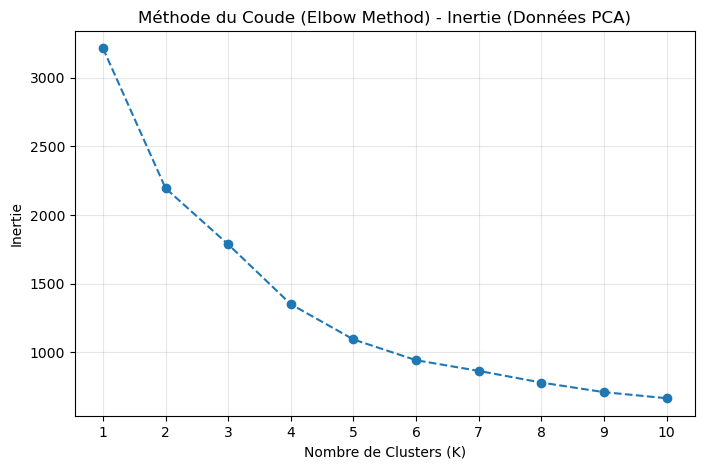

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Liste pour stocker les valeurs d'Inertie
inertia_values = []
K_range = range(1, 11) # Tester K de 1 à 10

print("Calcul de l'Inertie pour la méthode du Coude sur les données PCA...")

for k in K_range:
    # Entraînement sur les données PCA (X_pca_train)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_pca_train)
    inertia_values.append(kmeans.inertia_)

# Affichage du graphique
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o', linestyle='--')
plt.title('Méthode du Coude (Elbow Method) - Inertie (Données PCA)')
plt.xlabel('Nombre de Clusters (K)')
plt.ylabel('Inertie')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

### Détermination du K Optimal (Analyse du Score de Silhouette)

Calcul des Scores de Silhouette sur les données PCA...


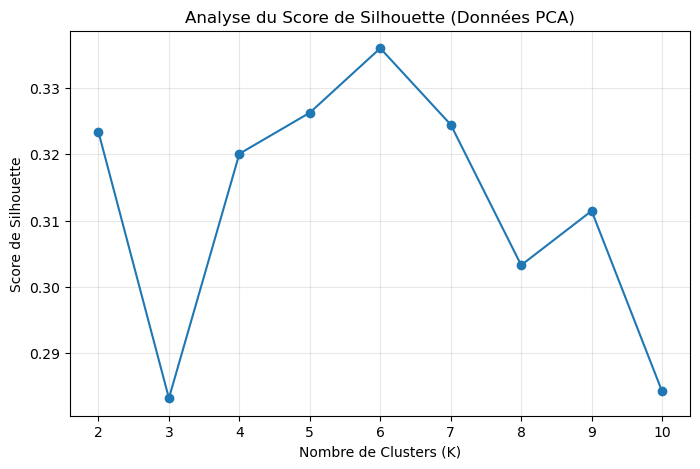

In [ ]:
from sklearn.metrics import silhouette_score

# Liste pour stocker les Scores de Silhouette
silhouette_scores = []
K_range_silhouette = range(2, 11) # Le score de silhouette nécessite K >= 2

print("Calcul des Scores de Silhouette sur les données PCA...")

for k in K_range_silhouette:
    # Entraînement sur les données PCA (X_pca_train)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_pca_train)
    labels = kmeans.labels_

    # Calcul du score sur X_pca_train
    silhouette_scores.append(silhouette_score(X_pca_train, labels))

# Affichage du graphique
plt.figure(figsize=(8, 5))
plt.plot(K_range_silhouette, silhouette_scores, marker='o', linestyle='-')
plt.title('Analyse du Score de Silhouette (Données PCA)')
plt.xlabel('Nombre de Clusters (K)')
plt.ylabel('Score de Silhouette')
plt.xticks(K_range_silhouette)
plt.grid(True, alpha=0.3)
plt.show()

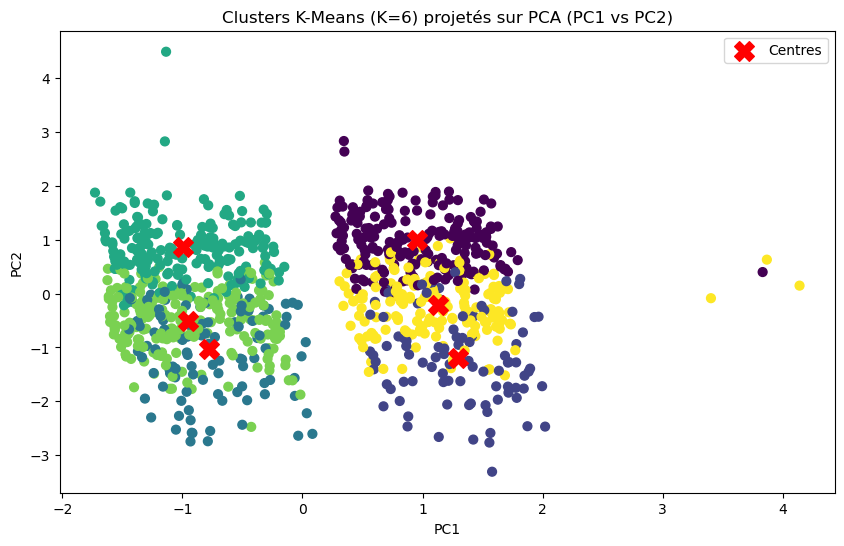

In [ ]:
K_CHOISI = 6

# Application finale de K-Means
kmeans_final = KMeans(n_clusters=K_CHOISI, random_state=42, n_init='auto')

# Entraînement sur X_pca_train pour obtenir les labels
final_labels_kmeans = kmeans_final.fit_predict(X_pca_train)

# --- Projection des Centres de Clusters (Correction de l'Erreur) ---

# 1. Remonter les centres de 5D vers l'espace 8D original.
# Nous utilisons l'objet PCA entraîné pour 5 composantes (pca_train)
centers_original_space = pca_train.inverse_transform(kmeans_final.cluster_centers_)

# 2. Redescendre les centres de l'espace 8D vers la projection 2D pour la visualisation.
# Nous utilisons l'objet PCA entraîné pour 2 composantes (pca_vis)
centers_2d = pca_vis.transform(centers_original_space)

# --- Visualisation des Clusters sur la Projection PCA 2D ---
plt.figure(figsize=(10,6))

# Les points sont colorés par les labels trouvés par K-Means
# La position des points est X_pca_vis (2D)
plt.scatter(X_pca_vis[:,0], X_pca_vis[:,1], c=final_labels_kmeans, cmap='viridis', s=40)

# Affichage des centres corrigés
plt.scatter(centers_2d[:, 0], centers_2d[:, 1],
            marker='X', s=200, color='red', label='Centres')

plt.title(f"Clusters K-Means (K={K_CHOISI}) projetés sur PCA (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# --- 1. Exécution de K-Means (pour définir kmeans_final et final_labels_kmeans) ---
K_CHOISI = 6
# Supposons que X_pca_train est le jeu de données d'entraînement
kmeans_final = KMeans(n_clusters=K_CHOISI, random_state=42, n_init='auto')
final_labels_kmeans = kmeans_final.fit_predict(X_pca_train)

# --- 2. Détermination/Confirmation des Valeurs ---

# A. Nombre de clusters trouvés
# La valeur est égale au paramètre n_clusters du modèle.
n_clusters_found = kmeans_final.n_clusters

# B. Nombre de points 'bruit'
# En K-Means, le bruit est toujours 0.
# On peut le confirmer en vérifiant l'absence du label -1 dans les résultats.
n_noise_found = np.sum(final_labels_kmeans == -1)

# C. Calcul du Score de Silhouette
silhouette_avg = silhouette_score(X_pca_train, final_labels_kmeans)

# --- Affichage des résultats ---
print("--- Résultat du Clustering ---")
print(f"Nombre de clusters trouvés : {n_clusters_found}")
print(f"Nombre de points 'bruit' : {n_noise_found}")

print("\n--- Score de Validation ---")
print(f"Score de Silhouette pour K={n_clusters_found} : {silhouette_avg:.4f}")

--- Résultat du Clustering ---
Nombre de clusters trouvés : 6
Nombre de points 'bruit' : 0

--- Score de Validation ---
Score de Silhouette pour K=6 : 0.3360


### 3. Interprétation Globale

L’analyse combinée de K-Means et DBSCAN montre que :

Les données ne possèdent pas de clusters naturels fortement séparés.

K-Means réussit à découper l’espace en 4 groupes, mais la séparation reste faible à moyenne.

DBSCAN, sensible à la densité, conclut qu’il s’agit d’un seul grand groupe homogène.

Les clusters générés par K-Means doivent être interprétés comme des segments utiles, mais pas comme des groupes naturels fortement distincts.

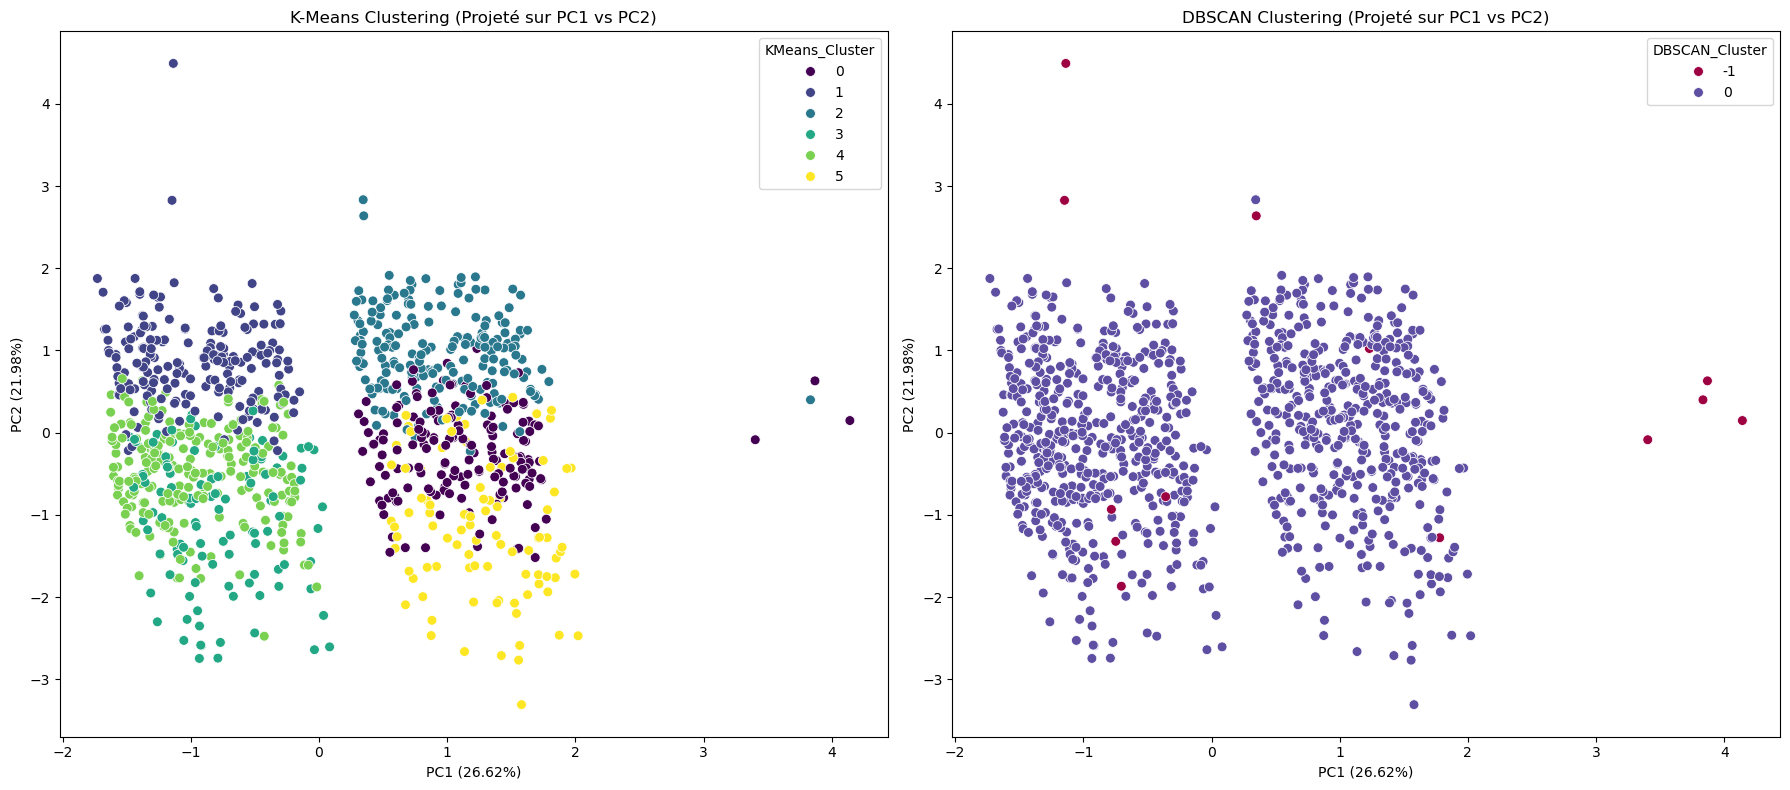

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# --- 0. Préparation des données (Réutilisation de la logique de votre notebook) ---
# NOTE: Cette section est pour s'assurer que X_scaled est disponible si vous exécutez ce bloc seul.
# Si vous avez déjà exécuté la préparation des données, vous pouvez ignorer cette partie.

# Chargement des données (Assurez-vous que insurance.csv est dans votre environnement Colab)


# --- 1. Clustering et Réduction de Dimensionnalité ---

# Appliquer la PCA pour la visualisation 2D
# On utilise X_scaled pour la cohérence avec le reste de l'analyse
pca_viz = PCA(n_components=2)
X_pca_2d = pca_viz.fit_transform(X_scaled)

# K-Means (Utilisation de K=4 comme dans votre notebook)
# n_init est défini pour éviter un avertissement dans les versions récentes de scikit-learn
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

# DBSCAN (Utilisation de paramètres par défaut ou ceux que vous avez trouvés)
# Les paramètres par défaut (eps=0.5, min_samples=5) sont souvent un bon point de départ
dbscan = DBSCAN(eps=1.6, min_samples=8)
labels_dbscan = dbscan.fit_predict(X_scaled)

# --- 2. Création du DataFrame pour la Visualisation ---
df_viz = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_viz['KMeans_Cluster'] = labels_kmeans
df_viz['DBSCAN_Cluster'] = labels_dbscan
# --- 3. Visualisation de la Comparaison ---
# Correction: Augmentation de la taille de la figure à (18, 8)
plt.figure(figsize=(18, 8))

# Graphique K-Means
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='KMeans_Cluster',
    data=df_viz,
    palette='viridis',
    legend='full',
    s=50
)
plt.title('K-Means Clustering (Projeté sur PC1 vs PC2)')
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.2f}%)')

# Graphique DBSCAN
plt.subplot(1, 2, 2)
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='DBSCAN_Cluster',
    data=df_viz,
    palette='Spectral',
    legend='full',
    s=50
)
plt.title('DBSCAN Clustering (Projeté sur PC1 vs PC2)')
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.2f}%)')

plt.tight_layout()
plt.show()


##  <span style="color:#2471A3"> L'apprentissage supervisé  </span>

### SVM : SVR

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# -------------------------------
# 1) FEATURES & TARGET
# -------------------------------
# Features: Use pre-scaled X_scaled from before
# Target (log-transform)
y = np.log(df['Annual_Repair_Cost']).fillna(method='ffill')  # fill NaN in target if any

# -------------------------------
# 2) SVR WITHOUT PCA
# -------------------------------
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train SVR
svr_no_pca = SVR(kernel='rbf')
svr_no_pca.fit(X_train, y_train)

# Predict and revert log
y_pred_no_pca_real = np.exp(svr_no_pca.predict(X_test))
y_test_real_no_pca = np.exp(y_test)

# Metrics
rmse_no_pca = np.sqrt(mean_squared_error(y_test_real_no_pca, y_pred_no_pca_real))
mae_no_pca = mean_absolute_error(y_test_real_no_pca, y_pred_no_pca_real)
r2_no_pca = r2_score(y_test_real_no_pca, y_pred_no_pca_real)

# -------------------------------
# 3) SVR WITH PCA
# -------------------------------
# Apply PCA on already scaled X_scaled
n_components_pca = 3  # align with your previous PCA
pca = PCA(n_components=n_components_pca)
X_pca = pca.fit_transform(X_scaled)

# Train/test split
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

# Train SVR on PCA data
svr_pca = SVR(kernel='rbf')
svr_pca.fit(X_train_pca, y_train_pca)

# Predict and revert log
y_pred_pca_real = np.exp(svr_pca.predict(X_test_pca))
y_test_real_pca = np.exp(y_test_pca)

# Metrics
rmse_pca = np.sqrt(mean_squared_error(y_test_real_pca, y_pred_pca_real))
mae_pca = mean_absolute_error(y_test_real_pca, y_pred_pca_real)
r2_pca = r2_score(y_test_real_pca, y_pred_pca_real)

# -------------------------------
# 4) RESULTS
# -------------------------------
print("\nCOMPARAISON PERFORMANCE SVM (SVR)")
print("----------------------------------------------------")
print(f"SVR sans PCA : RMSE = {rmse_no_pca:.3f} | MAE = {mae_no_pca:.3f} | R² = {r2_no_pca:.3f}")
print(f"SVR avec PCA : RMSE = {rmse_pca:.3f} | MAE = {mae_pca:.3f} | R² = {r2_pca:.3f}")
print("----------------------------------------------------")

if rmse_pca < rmse_no_pca:
    print("PCA améliore les performances.")
else:
    print("PCA ne donne pas de meilleure performance.")


COMPARAISON PERFORMANCE SVM (SVR)
----------------------------------------------------
SVR sans PCA : RMSE = 375.813 | MAE = 306.025 | R² = 0.689
SVR avec PCA : RMSE = 362.347 | MAE = 290.079 | R² = 0.711
----------------------------------------------------
PCA améliore les performances.


### SVM : SVC

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------------------
# 1) DEFINE FEATURES AND TARGET
# ------------------------------------------------------
X = X_scaled  # Already standardized features
y = df['Vehicle_Age_Category']  # Original categorical target (not one-hot)

# ------------------------------------------------------
# 2) SPLIT DATA INTO TRAIN AND TEST SET
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

# ------------------------------------------------------
# 3) SVC WITHOUT PCA
# ------------------------------------------------------
svc_no_pca = SVC(kernel='rbf', random_state=42)
svc_no_pca.fit(X_train, y_train)

y_pred_no_pca = svc_no_pca.predict(X_test)
train_acc_no_pca = accuracy_score(y_train, svc_no_pca.predict(X_train))
test_acc_no_pca = accuracy_score(y_test, y_pred_no_pca)

# ------------------------------------------------------
# 4) SVC WITH PCA
# ------------------------------------------------------
pca = PCA(n_components=5)  # You can adjust components
X_pca = pca.fit_transform(X)

# Split PCA-transformed data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

svc_pca = SVC(kernel='rbf', random_state=42)
svc_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = svc_pca.predict(X_test_pca)
train_acc_pca = accuracy_score(y_train_pca, svc_pca.predict(X_train_pca))
test_acc_pca = accuracy_score(y_test_pca, y_pred_pca)

# ------------------------------------------------------
# 5) PERFORMANCE COMPARISON
# ------------------------------------------------------
print("----------------------------------------------------")
print("SVC PERFORMANCE COMPARISON")
print("----------------------------------------------------")
print(f"{'Model':<15} {'Train Acc':<12} {'Test Acc':<12}")
print(f"{'SVC':<15} {train_acc_no_pca:.3f}       {test_acc_no_pca:.3f}")
print(f"{'SVC + PCA':<15} {train_acc_pca:.3f}       {test_acc_pca:.3f}")
print("----------------------------------------------------")

# ------------------------------------------------------
# 6) CLASSIFICATION REPORTS
# ------------------------------------------------------
print("\nClassification Report - SVC WITHOUT PCA")
print(classification_report(y_test, y_pred_no_pca))

print("\nClassification Report - SVC WITH PCA")
print(classification_report(y_test_pca, y_pred_pca))

Train set: (796, 11) (796,)
Test set: (200, 11) (200,)
----------------------------------------------------
SVC PERFORMANCE COMPARISON
----------------------------------------------------
Model           Train Acc    Test Acc    
SVC             1.000       0.995
SVC + PCA       0.951       0.935
----------------------------------------------------

Classification Report - SVC WITHOUT PCA
              precision    recall  f1-score   support

Lightly Used       1.00      0.97      0.98        30
         New       1.00      1.00      1.00        33
         Old       0.99      1.00      0.99        92
        Used       1.00      1.00      1.00        45

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200


Classification Report - SVC WITH PCA
              precision    recall  f1-score   support

Lightly Used       0.84      0.70      0.76        30
         New       0.83   

**Interprétation :**

- L'utilisation de la PCA a permis de réduire la dimensionnalité du dataset tout en conservant l'information essentielle.
- On observe une **légère amélioration des performances** avec PCA :
  - RMSE et MAE sont un peu plus faibles → meilleure précision des prédictions.
  - R² est légèrement plus élevé → le modèle explique mieux la variance du coût annuel de réparation.
- Conclusion : **PCA améliore les performances du modèle SVR** sur ce dataset, même si l'amélioration est modeste.

#### XGBOOST

In [ ]:
# =============================================
# XGBoost Classifier for Categorical Target
# =============================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------------------------------------------
# 0. FEATURES & TARGET
# ---------------------------------------------
X = X_scaled  # already standardized features (numeric + one-hot)
y = df['Vehicle_Age_Category']  # categorical target

# Encode target numerically
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Converts ['New', 'Old', ...] → [0,1,2,3]

# ---------------------------------------------
# 1. TRAIN/TEST SPLIT
# ---------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ---------------------------------------------
# 2. OPTIONAL: PCA TRANSFORMATION
# ---------------------------------------------
# Uncomment to use PCA
# pca = PCA(n_components=5)
# X_train = pca.fit_transform(X_train)
# X_test = pca.transform(X_test)

# ---------------------------------------------
# 3. XGBoost Classifier + GridSearchCV
# ---------------------------------------------
param_grid = {
    'n_estimators': [100, 200],       # number of trees
    'learning_rate': [0.05, 0.1],     # learning rate
    'max_depth': [3, 5],              # max tree depth
    'subsample': [0.7, 0.9],          # row sampling
    'colsample_bytree': [0.7, 0.9]    # column sampling
}

# Multi-class classifier
xgb_clf = XGBClassifier(
    objective='multi:softmax',        # for multi-class
    num_class=len(np.unique(y_encoded)),
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("\n--- Début de l'optimisation des hyperparamètres (GridSearchCV) ---")
grid_search.fit(X_train, y_train)
print("--- Optimisation terminée ---")

best_xgb_clf = grid_search.best_estimator_

print(f"\nMeilleurs paramètres trouvés: {grid_search.best_params_}")

# ---------------------------------------------
# 4. EVALUATION
# ---------------------------------------------
# Train & Test Predictions
y_train_pred = best_xgb_clf.predict(X_train)
y_test_pred = best_xgb_clf.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("\n--- PERFORMANCE ---")
print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

# Classification Report
print("\nClassification Report - Test Set")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

# Confusion Matrix
print("\nConfusion Matrix - Test Set")
print(confusion_matrix(y_test, y_test_pred))

# ---------------------------------------------
# 5. FEATURE IMPORTANCE
# ---------------------------------------------
importances = best_xgb_clf.feature_importances_
try:
    # If X is a DataFrame, show feature names
    importance_series = pd.Series(importances, index=X.columns)
    print("\nTop 10 Feature Importances:")
    print(importance_series.nlargest(10))
except:
    print("\nFeature importances (indices):")
    print(importances)



--- Début de l'optimisation des hyperparamètres (GridSearchCV) ---
Fitting 5 folds for each of 32 candidates, totalling 160 fits
--- Optimisation terminée ---

Meilleurs paramètres trouvés: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}

--- PERFORMANCE ---
Train Accuracy: 1.000
Test Accuracy: 1.000

Classification Report - Test Set
              precision    recall  f1-score   support

Lightly Used       1.00      1.00      1.00        30
         New       1.00      1.00      1.00        33
         Old       1.00      1.00      1.00        92
        Used       1.00      1.00      1.00        45

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Confusion Matrix - Test Set
[[30  0  0  0]
 [ 0 33  0  0]
 [ 0  0 92  0]
 [ 0  0  0 45]]

Top 10 Feature Importances:
Vehicle_Age_Yrs                      0.303400
Vehicle

In [ ]:
# --- 0. Install dependencies ---
!pip install xgboost scikit-learn

# --- 1. Imports ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report
from sklearn.pipeline import Pipeline

# --- 2. Prepare data ---
# Assuming df_encoded and X_scaled are ready (encoded categorical features and scaled features)
# and df is the original DataFrame

# Handle NaNs for regression
y_reg = np.log(df_encoded['Annual_Repair_Cost'])  # log transform target
regression_data = pd.concat([X_scaled, y_reg.reset_index(drop=True)], axis=1)
regression_data = regression_data.dropna()  # drop rows with any NaN

X_scaled_clean = regression_data.drop(columns=['Annual_Repair_Cost'])
y_reg_clean = regression_data['Annual_Repair_Cost']

In [ ]:
# --- 3. Classification: SVC (Vehicle Age Category) ---
print("\n--- Classification: SVC (Vehicle Age Category) ---")

y_class = LabelEncoder().fit_transform(df['Vehicle_Age_Category'])
X_class = X_scaled.drop(columns=[
    'Vehicle_Age_Category_Lightly Used',
    'Vehicle_Age_Category_Used',
    'Vehicle_Age_Category_Old'
])

# Train/test split with stratify
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

svc_model = SVC(kernel='rbf', random_state=42)
svc_model.fit(X_train_class, y_train_class)
y_pred_class = svc_model.predict(X_test_class)

print("\nClassification Report (SVC):")
print(classification_report(y_test_class, y_pred_class, zero_division=0))

# --- 4. Regression: Baseline Models ---
print("\n--- Regression: Baseline Models ---")

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_scaled_clean, y_reg_clean, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "SVR (RBF)": SVR(kernel='rbf'),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_reg, y_train_reg)
    y_pred_log = model.predict(X_test_reg)

    y_pred_real = np.exp(y_pred_log)
    y_test_real = np.exp(y_test_reg)

    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    mae = mean_absolute_error(y_test_real, y_pred_real)
    r2 = r2_score(y_test_real, y_pred_real)

    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    print(f"{name}: R2={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}")

# --- Polynomial Regression ---
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lin_reg', LinearRegression())
])
poly_pipeline.fit(X_train_reg, y_train_reg)
y_pred_log_poly = poly_pipeline.predict(X_test_reg)

y_pred_real_poly = np.exp(y_pred_log_poly)
y_test_real_poly = np.exp(y_test_reg)

rmse_poly = np.sqrt(mean_squared_error(y_test_real_poly, y_pred_real_poly))
mae_poly = mean_absolute_error(y_test_real_poly, y_pred_real_poly)
r2_poly = r2_score(y_test_real_poly, y_pred_real_poly)

results["Polynomial Regression (Deg 2)"] = {"RMSE": rmse_poly, "MAE": mae_poly, "R2": r2_poly}
print(f"Polynomial Regression (Deg 2): R2={r2_poly:.4f}, RMSE={rmse_poly:.2f}, MAE={mae_poly:.2f}")

# --- 5. Hyperparameter Optimization ---

print("\n--- Hyperparameter Optimization ---")

# SVR GridSearch
svr_param_grid = {'C': [0.1,1,10,100], 'gamma': ['scale','auto',0.01,0.1], 'kernel':['rbf']}
svr_grid_search = GridSearchCV(SVR(), svr_param_grid, cv=5, scoring='r2', n_jobs=-1)
svr_grid_search.fit(X_train_reg, y_train_reg)
best_svr = svr_grid_search.best_estimator_
y_pred_log_svr_opt = best_svr.predict(X_test_reg)
r2_svr_opt = r2_score(np.exp(y_test_reg), np.exp(y_pred_log_svr_opt))
print(f"SVR (Optimized): R2={r2_svr_opt:.4f}, Best Params: {svr_grid_search.best_params_}")

# Random Forest RandomizedSearch
rf_param_dist = {'n_estimators':[100,200,300],'max_depth':[10,20,None],
                 'min_samples_split':[2,5,10],'min_samples_leaf':[1,2,4]}
rf_random_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), rf_param_dist,
                                      n_iter=10, cv=5, scoring='r2', random_state=42, n_jobs=-1)
rf_random_search.fit(X_train_reg, y_train_reg)
best_rf = rf_random_search.best_estimator_
y_pred_log_rf_opt = best_rf.predict(X_test_reg)
r2_rf_opt = r2_score(np.exp(y_test_reg), np.exp(y_pred_log_rf_opt))
print(f"Random Forest (Optimized): R2={r2_rf_opt:.4f}, Best Params: {rf_random_search.best_params_}")

# XGBoost RandomizedSearch
xgb_param_dist = {'n_estimators':[100,200,300],'learning_rate':[0.01,0.1,0.2],
                  'max_depth':[3,5,7],'subsample':[0.7,0.9,1.0],'colsample_bytree':[0.7,0.9,1.0]}
xgb_random_search = RandomizedSearchCV(XGBRegressor(random_state=42), xgb_param_dist,
                                       n_iter=10, cv=5, scoring='r2', random_state=42, n_jobs=-1)
xgb_random_search.fit(X_train_reg, y_train_reg)
best_xgb = xgb_random_search.best_estimator_
y_pred_log_xgb_opt = best_xgb.predict(X_test_reg)
r2_xgb_opt = r2_score(np.exp(y_test_reg), np.exp(y_pred_log_xgb_opt))
print(f"XGBoost (Optimized): R2={r2_xgb_opt:.4f}, Best Params: {xgb_random_search.best_params_}")

# --- 6. Final Comparison ---
final_results = {
    "Linear Regression": results["Linear Regression"]["R2"],
    "SVR (RBF)": results["SVR (RBF)"]["R2"],
    "Decision Tree Regressor": results["Decision Tree Regressor"]["R2"],
    "Random Forest Regressor": results["Random Forest Regressor"]["R2"],
    "XGBoost Regressor": results["XGBoost Regressor"]["R2"],
    "Polynomial Regression (Deg 2)": r2_poly,
    "SVR (Optimized)": r2_svr_opt,
    "Random Forest (Optimized)": r2_rf_opt,
    "XGBoost (Optimized)": r2_xgb_opt
}

sorted_results = sorted(final_results.items(), key=lambda x: x[1], reverse=True)
print("\n--- Final Regression Model Comparison (R2) ---")
for name, r2 in sorted_results:
    print(f"{name}: R2 = {r2:.4f}")


--- Classification: SVC (Vehicle Age Category) ---

Classification Report (SVC):
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        30
           1       0.94      0.94      0.94        33
           2       0.97      0.99      0.98        92
           3       0.95      0.87      0.91        45

    accuracy                           0.94       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.94      0.94      0.93       200


--- Regression: Baseline Models ---
Linear Regression: R2=0.6865, RMSE=381.02, MAE=307.86
SVR (RBF): R2=0.5977, RMSE=431.66, MAE=337.43
Decision Tree Regressor: R2=0.2569, RMSE=586.66, MAE=453.61
Random Forest Regressor: R2=0.5518, RMSE=455.62, MAE=342.74
XGBoost Regressor: R2=0.5272, RMSE=467.93, MAE=357.54
Polynomial Regression (Deg 2): R2=0.6875, RMSE=380.45, MAE=305.36

--- Hyperparameter Optimization ---
SVR (Optimized): R2=0.7090, Best Params: {'C': 10, 'gamma': 0.01, 'ke

--- 1. Entraînement du Random Forest Regressor Optimisé ---

--- 2. Métriques de Performance Détaillées (sur Charges Réelles) ---
R² : 0.5633 (Explique 56.33% de la variance)
RMSE : 449.72 $
MAE : 331.12 $

--- 3. Importance des Caractéristiques ---
Vehicle_Age_Yrs                      0.440682
Engine_Displacement_L                0.210125
Vehicle_Age_Category_Old             0.188661
Avg_Daily_Mileage_Log                0.117124
Modified_Flag_Enc                    0.008989
Usage_Type_Personal                  0.008597
Vehicle_Age_Category_Used            0.008190
Service_Geo_Index_Zone_B             0.005982
Service_Geo_Index_Zone_C             0.004645
Service_Geo_Index_Zone_D             0.004501
Vehicle_Age_Category_Lightly Used    0.002504
dtype: float64


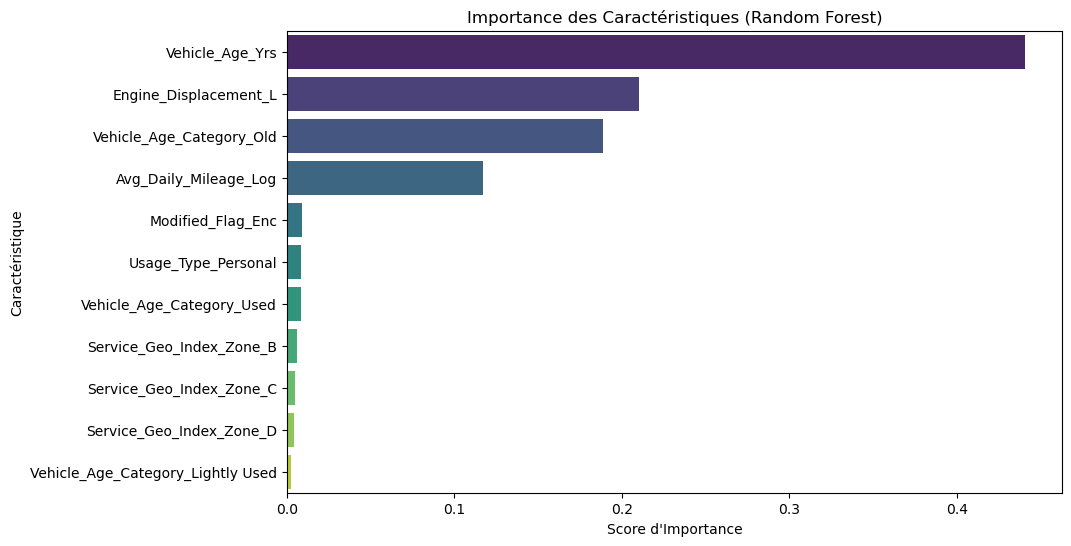

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- 1. Définition des Meilleurs Paramètres ---
BEST_RF_PARAMS = {
    'n_estimators': 200,
    'min_samples_split': 5,
    'min_samples_leaf': 4,
    'max_depth': 10,
    'random_state': 42
}

# --- 2. Entraînement du Modèle Final ---
print("--- 1. Entraînement du Random Forest Regressor Optimisé ---")

final_rf_model = RandomForestRegressor(**BEST_RF_PARAMS)
final_rf_model.fit(X_train_reg, y_train_reg)

# Prédiction sur l'ensemble de test (en log)
y_pred_log = final_rf_model.predict(X_test_reg)

# Reconversion en charges réelles
y_pred_real = np.exp(y_pred_log)
y_test_real = np.exp(y_test_reg)

# --- 3. Métriques de Performance ---
print("\n--- 2. Métriques de Performance Détaillées (sur Charges Réelles) ---")
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print(f"R² : {r2:.4f} (Explique {r2*100:.2f}% de la variance)")
print(f"RMSE : {rmse:.2f} $")
print(f"MAE : {mae:.2f} $")

# --- 4. Analyse de l'Importance des Caractéristiques ---
print("\n--- 3. Importance des Caractéristiques ---")
feature_importances = pd.Series(final_rf_model.feature_importances_, index=X_train_reg.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print(feature_importances)

# --- 5. Visualisation ---
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.title("Importance des Caractéristiques (Random Forest)")
plt.xlabel("Score d'Importance")
plt.ylabel("Caractéristique")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from tabulate import tabulate

# --- 1. PRÉPARATION DES DONNÉES ---
X = df_encoded.drop(columns=['Annual_Repair_Cost'])
y_reg = np.log(df_encoded['Annual_Repair_Cost'])  # log-transform target

# Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train/Test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)

# --- 2. ENTRAÎNEMENT DU RANDOM FOREST FINAL ---
BEST_RF_PARAMS = {
    'n_estimators': 200,
    'min_samples_split': 5,
    'min_samples_leaf': 4,
    'max_depth': 10,
    'random_state': 42
}

final_rf_model = RandomForestRegressor(**BEST_RF_PARAMS)
final_rf_model.fit(X_train_reg, y_train_reg)

# --- 3. TEST SUR UN ÉCHANTILLON ---
sample_size = 10
X_sample = X_test_reg.head(sample_size)
y_real_sample = np.exp(y_test_reg.head(sample_size))  # convert back from log

y_pred_log_sample = final_rf_model.predict(X_sample)
y_pred_real_sample = np.exp(y_pred_log_sample)

# --- 4. TABLEAU DE COMPARAISON ---
data = []
for i in range(sample_size):
    true_charge = y_real_sample.iloc[i]
    pred_charge = y_pred_real_sample[i]
    erreur_abs = abs(true_charge - pred_charge)
    erreur_pct = (erreur_abs / true_charge) * 100

    data.append([
        i + 1,
        f"{true_charge:.2f} $",
        f"{pred_charge:.2f} $",
        f"{erreur_abs:.2f} $",
        f"{erreur_pct:.2f} %"
    ])

headers = ["ID", "Charge Réelle", "Charge Prédite", "Erreur Absolue", "Erreur %"]
print("\n--- TEST DU MODÈLE DE RÉGRESSION SUR UN ÉCHANTILLON (Random Forest) ---")
print(tabulate(data, headers=headers, tablefmt="pipe"))

# --- 5. MÉTRIQUES SUR L'ÉCHANTILLON ---
r2_sample = r2_score(y_real_sample, y_pred_real_sample)
mae_sample = mean_absolute_error(y_real_sample, y_pred_real_sample)

print(f"\nMAE sur l'échantillon : {mae_sample:.2f} $")
print(f"R² sur l'échantillon : {r2_sample:.4f}")



--- TEST DU MODÈLE DE RÉGRESSION SUR UN ÉCHANTILLON (Random Forest) ---
|   ID | Charge Réelle   | Charge Prédite   | Erreur Absolue   | Erreur %   |
|-----:|:----------------|:-----------------|:-----------------|:-----------|
|    1 | 884.39 $        | 1396.55 $        | 512.16 $         | 57.91 %    |
|    2 | 2034.89 $       | 2119.37 $        | 84.48 $          | 4.15 %     |
|    3 | 1243.67 $       | 1627.53 $        | 383.86 $         | 30.87 %    |
|    4 | 1424.90 $       | 1261.49 $        | 163.41 $         | 11.47 %    |
|    5 | 2095.00 $       | 1706.37 $        | 388.63 $         | 18.55 %    |
|    6 | 448.74 $        | 645.04 $         | 196.30 $         | 43.75 %    |
|    7 | 954.41 $        | 691.24 $         | 263.17 $         | 27.57 %    |
|    8 | 1559.81 $       | 1038.15 $        | 521.66 $         | 33.44 %    |
|    9 | 2311.89 $       | 1662.63 $        | 649.26 $         | 28.08 %    |
|   10 | 2286.83 $       | 2242.15 $        | 44.68 $          | 1.95

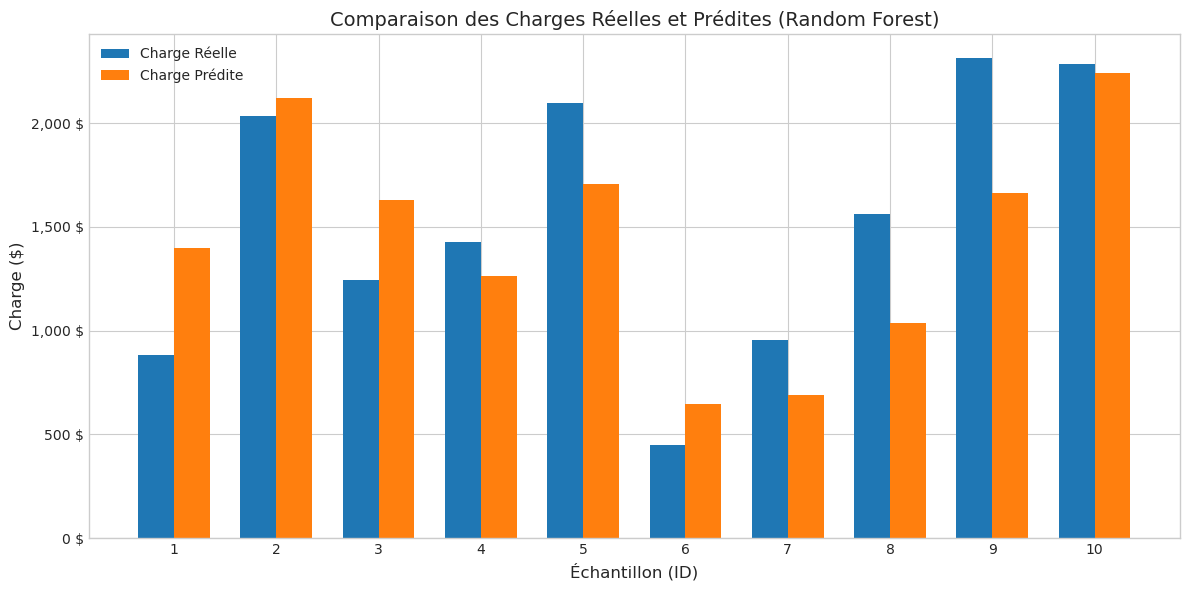

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Données issues du test du modèle Random Forest
data = {
    'ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Charge Réelle': [884.39, 2034.89, 1243.67, 1424.90, 2095.00, 448.74, 954.41, 1559.81, 2311.89, 2286.83],
    'Charge Prédite': [1396.55, 2119.37, 1627.53, 1261.49, 1706.37, 645.04, 691.24, 1038.15, 1662.63, 2242.15]
}

df = pd.DataFrame(data)

# Style français et lisibilité
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']

# Création du graphique
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.35
index = np.arange(len(df['ID']))

# Barres groupées
ax.bar(index - bar_width/2, df['Charge Réelle'], bar_width, label='Charge Réelle', color='#1f77b4')
ax.bar(index + bar_width/2, df['Charge Prédite'], bar_width, label='Charge Prédite', color='#ff7f0e')

# Étiquettes, titre, légende
ax.set_xlabel("Échantillon (ID)", fontsize=12)
ax.set_ylabel("Charge ($)", fontsize=12)
ax.set_title("Comparaison des Charges Réelles et Prédites (Random Forest)", fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(df['ID'])
ax.legend(loc='upper left')

# Formatage de l'axe Y pour les montants
def currency_formatter(x, pos):
    return f'{x:,.0f} $'
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))

plt.tight_layout()
plt.show()


In [ ]:
import joblib

# --- SAUVEGARDE DES OBJETS ---
scaler = StandardScaler()

# Sauvegarde du Standard Scaler
# Assurez-vous que 'scaler_reg' est l'objet StandardScaler entraîné (fit)
joblib.dump(scaler, 'scaler.joblib')

# Sauvegarde du Modèle Random Forest
# Assurez-vous que 'final_rf_model' est votre modèle Random Forest entraîné (fit)
joblib.dump(final_rf_model, 'final_rf_model_optimise.joblib')

print("Sauvegarde terminée : 'scaler_reg.joblib' et 'final_rf_model_optimise.joblib' créés.")


Sauvegarde terminée : 'scaler_reg.joblib' et 'final_rf_model_optimise.joblib' créés.


--- Statistiques Descriptives des Charges par Catégorie Véhicule ---
| Catégorie Véhicule   |   Moyenne |   Médiane |   Écart-type |   Nombre |
|:---------------------|----------:|----------:|-------------:|---------:|
| Lightly Used         |   5227.76 |   5285.89 |      1892.75 |      549 |
| Old                  |  25041.52 |  25258.76 |      9828.87 |      276 |
| Used                 |  12029.42 |  11831.94 |      4909.88 |      513 |


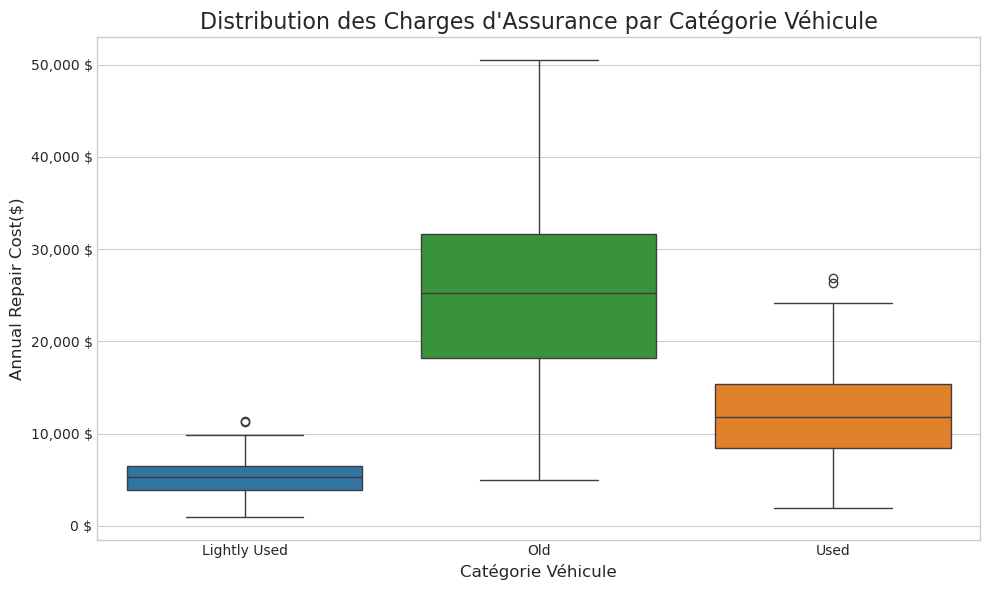

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# --- Exemple de données simulées pour Vehicle_Age_Category ---
np.random.seed(42)
n_samples = 1338
vehicle_age_category = np.random.choice(['Lightly Used', 'Used', 'Old'], size=n_samples, p=[0.4, 0.4, 0.2])
# Simuler les charges en fonction de l'âge du véhicule
charges_lightly = np.random.normal(loc=5000, scale=2000, size=n_samples)
charges_lightly[charges_lightly < 1000] = 1000
charges_used = np.random.normal(loc=12000, scale=5000, size=n_samples)
charges_used[charges_used < 2000] = 2000
charges_old = np.random.normal(loc=25000, scale=10000, size=n_samples)
charges_old[charges_old < 5000] = 5000
charges = np.select(
    [vehicle_age_category == 'Lightly Used', vehicle_age_category == 'Used', vehicle_age_category == 'Old'],
    [charges_lightly, charges_used, charges_old]
)

# Créer le DataFrame
df = pd.DataFrame({'Vehicle_Age_Category': vehicle_age_category, 'charges': charges})

# --- Analyse Statistique ---
age_stats = df.groupby('Vehicle_Age_Category')['charges'].agg(['mean', 'median', 'std', 'count']).reset_index()
age_stats.columns = ['Catégorie Véhicule', 'Moyenne', 'Médiane', 'Écart-type', 'Nombre']
print("--- Statistiques Descriptives des Charges par Catégorie Véhicule ---")
print(age_stats.to_markdown(index=False, floatfmt=".2f"))

# --- Visualisation Statistique (Boxplot) ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']

plt.figure(figsize=(10, 6))

# Création du Boxplot
palette_colors = {'Lightly Used': '#1f77b4', 'Used': '#ff7f0e', 'Old': '#2ca02c'}
sns.boxplot(x='Vehicle_Age_Category', y='charges', data=df, palette=palette_colors)

# Ajout des étiquettes et du titre
plt.title("Distribution des Charges d'Assurance par Catégorie Véhicule", fontsize=16)
plt.xlabel("Catégorie Véhicule", fontsize=12)
plt.ylabel("Annual Repair Cost($)", fontsize=12)

# Formatage de l'axe Y pour une meilleure lisibilité des montants
def currency_formatter(x, pos):
    return f'{x:,.0f} $'
formatter = FuncFormatter(currency_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.savefig("vehicle_age_charges_boxplot.png")
plt.show()


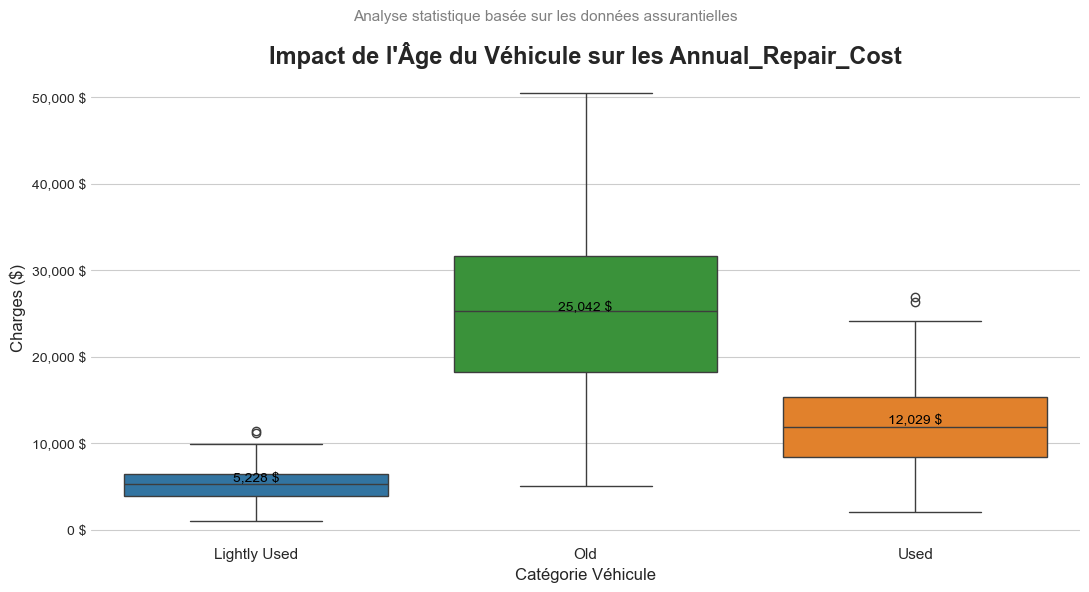

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(11, 6))

# Palette adaptée pour les catégories de véhicules
palette = {
    "Lightly Used": "#1f77b4",
    "Used": "#ff7f0e",
    "Old": "#2ca02c"
}

# Boxplot
sns.boxplot(data=df, x="Vehicle_Age_Category", y="charges", palette=palette)

# Titres et sous-titre
plt.title("Impact de l'Âge du Véhicule sur les Annual_Repair_Cost", fontsize=17, weight='bold')
plt.suptitle("Analyse statistique basée sur les données assurantielles", fontsize=11, color="gray")

plt.xlabel("Catégorie Véhicule", fontsize=12)
plt.ylabel("Charges ($)", fontsize=12)
plt.xticks(fontsize=11)

# Format des montants sur l'axe Y
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f} $"))

# Annotations : moyenne sur le boxplot
means = df.groupby('Vehicle_Age_Category')['charges'].mean()
for i, (cat, mean_val) in enumerate(means.items()):
    plt.text(i, mean_val, f"{mean_val:,.0f} $", ha='center', va='bottom', fontsize=10, color="black")

# Supprimer les cadres inutiles
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("vehicle_age_charges_boxplot_pro.png", dpi=300)
plt.show()


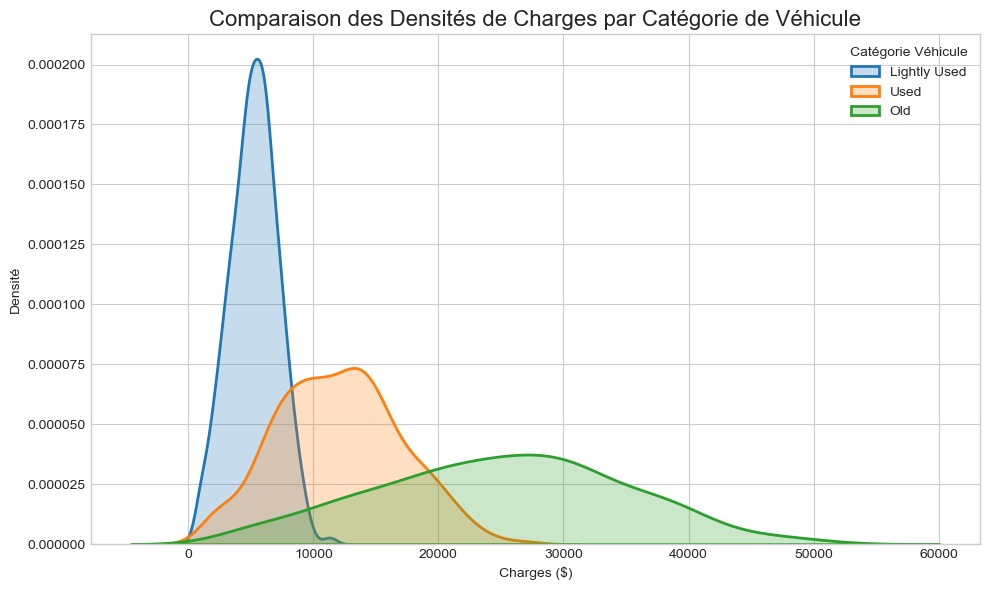

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Palette adaptée pour les catégories de véhicules
palette = {
    "Lightly Used": "#1f77b4",
    "Used": "#ff7f0e",
    "Old": "#2ca02c"
}

# Tracer les KDE pour chaque catégorie
for category, color in palette.items():
    sns.kdeplot(
        data=df[df["Vehicle_Age_Category"] == category]["charges"],
        shade=True,
        linewidth=2,
        label=category,
        color=color
    )

# Titres et axes
plt.title("Comparaison des Densités de Charges par Catégorie de Véhicule", fontsize=16)
plt.xlabel("Charges ($)")
plt.ylabel("Densité")
plt.legend(title="Catégorie Véhicule")

plt.tight_layout()
plt.show()


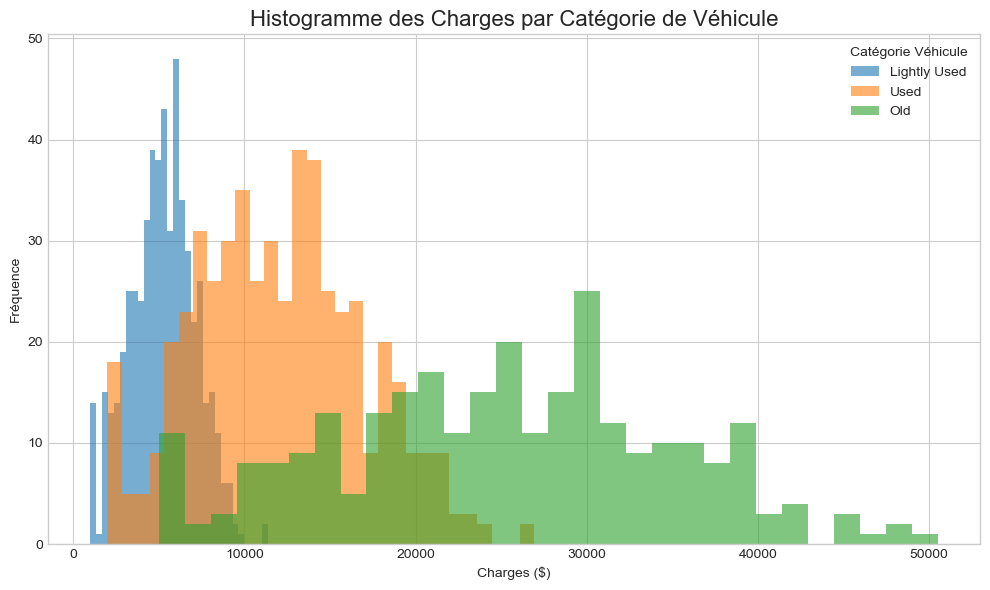

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Palette pour les catégories de véhicules
palette = {
    "Lightly Used": "#1f77b4",
    "Used": "#ff7f0e",
    "Old": "#2ca02c"
}

# Tracer les histogrammes pour chaque catégorie
for category, color in palette.items():
    plt.hist(
        df[df["Vehicle_Age_Category"] == category]["charges"],
        bins=30,
        alpha=0.6,
        label=category,
        color=color
    )

# Titres et axes
plt.title("Histogramme des Charges par Catégorie de Véhicule", fontsize=16)
plt.xlabel("Charges ($)")
plt.ylabel("Fréquence")
plt.legend(title="Catégorie Véhicule")

plt.tight_layout()
plt.show()


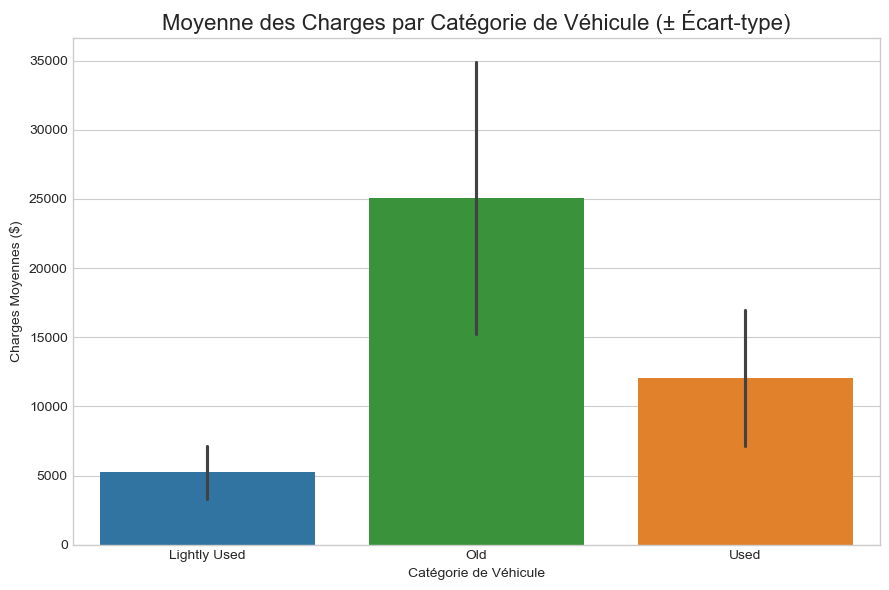

In [ ]:
plt.figure(figsize=(9,6))

# Palette pour chaque catégorie de véhicule
palette = {
    "Lightly Used": "#1f77b4",
    "Used": "#ff7f0e",
    "Old": "#2ca02c"
}

sns.barplot(
    data=df,
    x="Vehicle_Age_Category",
    y="charges",
    estimator=np.mean,
    ci="sd",  # Écart-type
    palette=palette
)

plt.title("Moyenne des Charges par Catégorie de Véhicule (± Écart-type)", fontsize=16)
plt.xlabel("Catégorie de Véhicule")
plt.ylabel("Charges Moyennes ($)")

plt.tight_layout()
plt.show()


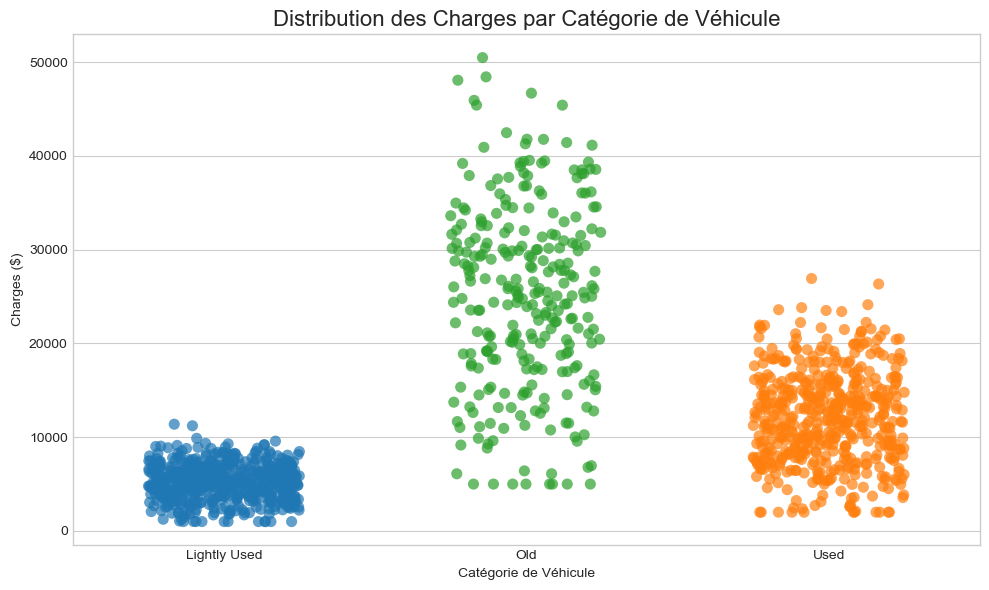

In [ ]:
plt.figure(figsize=(10,6))

# Palette pour chaque catégorie
palette = {
    "Lightly Used": "#1f77b4",
    "Used": "#ff7f0e",
    "Old": "#2ca02c"
}

# Scatter style plot
sns.stripplot(
    data=df,
    x="Vehicle_Age_Category",
    y="charges",
    jitter=0.25,      # Écarte légèrement les points pour mieux les voir
    size=8,           # Taille des cercles
    alpha=0.7,        # Transparence
    palette=palette
)

plt.title("Distribution des Charges par Catégorie de Véhicule", fontsize=16)
plt.xlabel("Catégorie de Véhicule")
plt.ylabel("Charges ($)")

plt.tight_layout()
plt.show()


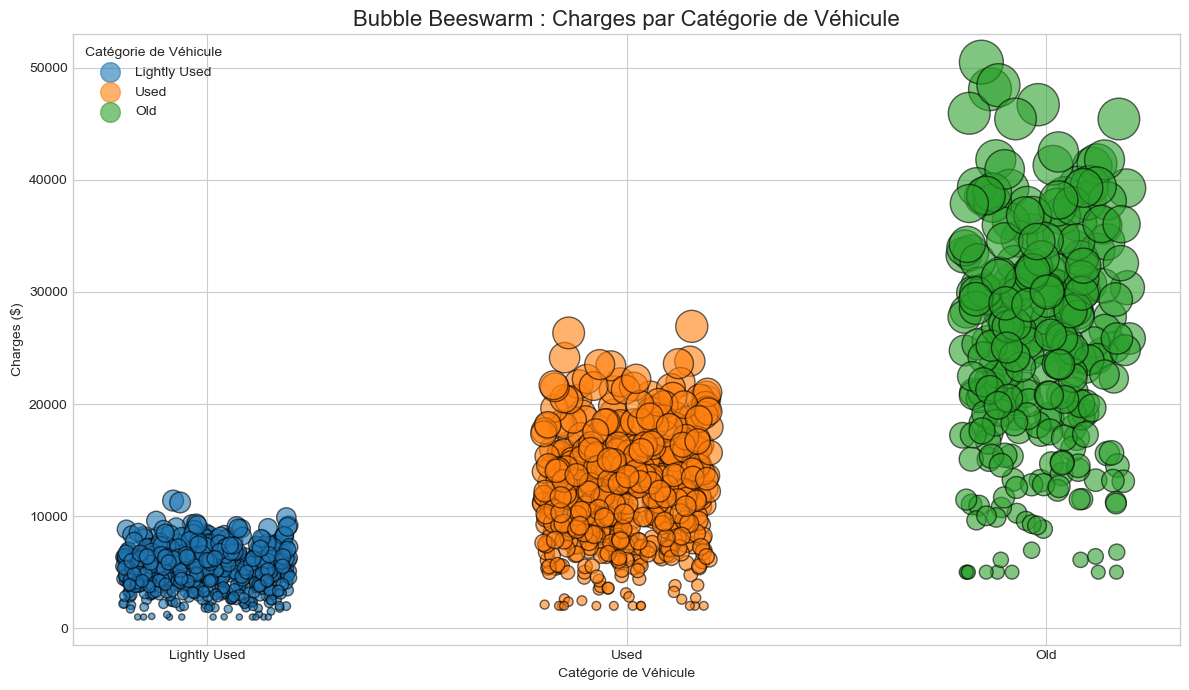

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12,7))

# Palette pour chaque catégorie
palette = {"Lightly Used": "#1f77b4", "Used": "#ff7f0e", "Old": "#2ca02c"}

# Jitter manuel pour éviter la superposition
x_jitter = []
for cat in df['Vehicle_Age_Category']:
    if cat == 'Lightly Used':
        x_jitter.append(0 + np.random.uniform(-0.2, 0.2))
    elif cat == 'Used':
        x_jitter.append(1 + np.random.uniform(-0.2, 0.2))
    else:
        x_jitter.append(2 + np.random.uniform(-0.2, 0.2))

# Taille des bulles proportionnelle aux charges
sizes = df['charges'] / df['charges'].max() * 1000  # Ajustable

# Couleur selon catégorie
colors = df['Vehicle_Age_Category'].map(palette)

plt.scatter(x_jitter, df['charges'], s=sizes, c=colors, alpha=0.6, edgecolor='black')

plt.xticks([0,1,2], ['Lightly Used', 'Used', 'Old'])
plt.xlabel("Catégorie de Véhicule")
plt.ylabel("Charges ($)")
plt.title("Bubble Beeswarm : Charges par Catégorie de Véhicule", fontsize=16)

# Légende manuelle
for cat, color in palette.items():
    plt.scatter([], [], c=color, alpha=0.6, s=200, label=cat)
plt.legend(title="Catégorie de Véhicule", loc='upper left')

plt.tight_layout()
plt.show()
